# DHL Last-Mile VRP per Postal Code – VROOM + Valhalla

This notebook constructs and solves Vehicle Routing Problems (VRP) for DHL parcel delivery in the Hannover region:
1. Reads the demand shapefile (DHL parcels per street segment)
2. Reads postal code (PLZ) areas from `geodata/plz_areas.csv`
3. Reads DHL hub locations from `hubs/KEP-hubs_v3.csv` and filters for DHL
4. Parses vehicle types from `vehicles/HAGRID_vehicleTypes2.0.xml` (ct_cep_size_l, capacity 230 parcels)
5. Assigns each postal code to the nearest DHL hub (Euclidean centroid distance)
6. Builds a VROOM VRP request (JSON) per postal code
7. Saves all requests to `requests/dhl_per_plz/`
8. Solves each VRP via the VROOM API with detailed runtime logging

In [ ]:
flowchart LR
    subgraph A["(a) Data"]
        A1[HAGRID weekly demand<br/>7 LSPs · PLZ · B2C/B2B]
        A2[Hubs + Vehicles]
        A3[OSM / Valhalla tiles]
    end
    subgraph B["(b) Baseline VRP"]
        B1[VROOM solve<br/>6×/week daily delivery]
    end
    subgraph C["(c) Surrogate"]
        C1[44 features<br/>spatial · demand · schedule]
        C2[MLP Ensemble ×5 seeds]
        C3[5-fold CV<br/>MAPE < 5%]
    end
    subgraph D["(d) Optimization"]
        D1[Coordinate Descent<br/>494 weekly patterns / PLZ]
        D2[Scenario I: + residual next-day]
        D3[Scenario II: batch-only]
    end
    subgraph E["(e) Fleet Balancing"]
        E1[Hub-level swap<br/>flatten daily vehicles]
    end
    subgraph F["(f) Evaluation"]
        F1[Re-solve VRP<br/>VROOM]
        F2[KPIs: € · km · fleet · wait]
        F3[Baseline vs I vs II]
    end
    A --> B --> C --> D --> E --> F
    F1 -. retrain .-> C2
    C2 -- predicted cost --> D1

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, json, math, re, time, logging
from pathlib import Path
from datetime import datetime
from xml.etree import ElementTree as ET

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely import wkt
import requests as req

# Configure logging for runtime analysis
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S'
)
log = logging.getLogger('DHL_VRP')
log.info('Imports loaded successfully')

12:13:38 [INFO] Imports loaded successfully


In [2]:
# ── Determine project root and output directories ────────────────────────────
ROOT = Path.cwd()
for _ in range(10):
    if (ROOT / 'docker-compose.yml').exists():
        break
    ROOT = ROOT.parent

INPUT   = ROOT / 'input'
OUT_DIR = ROOT / 'requests' / 'dhl_per_plz'
SOL_DIR = ROOT / 'results' / 'dhl_per_plz'
OUT_DIR.mkdir(parents=True, exist_ok=True)
SOL_DIR.mkdir(parents=True, exist_ok=True)

log.info(f'Project root: {ROOT}')
log.info(f'Request output: {OUT_DIR}')
log.info(f'Solution output: {SOL_DIR}')

12:13:41 [INFO] Project root: c:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover
12:13:41 [INFO] Request output: c:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\requests\dhl_per_plz
12:13:41 [INFO] Solution output: c:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\results\dhl_per_plz


## 1 – Load Demand Shapefile (DHL parcels)

In [3]:
# ── Load demand shapefile ────────────────────────────────────────────────────
# Source: MATSim-based parcel demand estimation for Hannover region (EPSG:25832)
shp_path = INPUT / 'demand' / 'vm-hochrechnung_matsim-punkte_epsg25832_mit_plz_v2.shp'
gdf_demand = gpd.read_file(shp_path)
log.info(f'Demand loaded: {len(gdf_demand)} rows, CRS={gdf_demand.crs}')
print(f'Columns: {list(gdf_demand.columns)}')
gdf_demand.head(10)

12:13:46 [INFO] Demand loaded: 46591 rows, CRS=EPSG:25832


Columns: ['matsim_id', 'dhl_tag', 'hermes_tag', 'ups_tag', 'amazon_tag', 'dpd_tag', 'gls_tag', 'fedex_tag', 'postal_cod', 'total', 'wl_tag', 'geometry']


,matsim_id,dhl_tag,hermes_tag,ups_tag,amazon_tag,dpd_tag,gls_tag,fedex_tag,postal_cod,total,wl_tag,geometry
0,100016,5,0,0,0,3,1,0,30890,9,9,MULTIPOINT ((528471.75 5798325.272))
1,100017,2,1,2,0,1,0,0,30890,6,6,MULTIPOINT ((528471.75 5798325.272))
2,1000185-369954,1,1,0,1,0,0,0,31515,3,3,MULTIPOINT ((524052.559 5810462.469))
3,1000186,0,0,1,0,0,0,0,31515,1,1,MULTIPOINT ((526228.779 5811984.64))
4,1000187,2,0,1,1,3,0,1,31515,8,8,MULTIPOINT ((526228.779 5811984.64))
5,1000188,0,0,0,0,0,0,0,31515,0,0,MULTIPOINT ((526371.907 5812023.085))
6,100019,7,1,5,3,1,1,1,30890,19,19,MULTIPOINT ((528550.443 5798248.343))
7,1000190,0,0,1,1,2,1,1,31515,6,6,MULTIPOINT ((526419.674 5812047.313))
8,1000192-687549-591674,3,0,0,0,0,1,0,31515,4,4,MULTIPOINT ((526532.652 5812073.996))
9,1000200,2,0,0,1,0,0,2,31515,5,5,MULTIPOINT ((525354.087 5811768.995))


In [21]:
# ── Filter for DHL demand: dhl_tag > 0, outlier threshold <= 450 ──────────────
# Column 'dhl_tag' contains estimated daily DHL parcel count per demand point
# Points with dhl_tag > 450 are unrealistic outliers and are removed
gdf_dhl = gdf_demand.copy()
if 'dhl_tag' in gdf_dhl.columns:
    gdf_dhl['dhl_tag'] = pd.to_numeric(gdf_dhl['dhl_tag'], errors='coerce').fillna(0).astype(int)
    n_before = len(gdf_dhl)
    gdf_dhl = gdf_dhl[gdf_dhl['dhl_tag'] > 0].copy()
    n_positive = len(gdf_dhl)
    n_outliers = (gdf_dhl['dhl_tag'] > 450).sum()
    gdf_dhl = gdf_dhl[gdf_dhl['dhl_tag'] <= 450].copy()  # remove outliers > 450
    log.info(f'After DHL filter: {len(gdf_dhl)} points (removed {n_before - n_positive} zero, {n_outliers} outliers > 450)')
else:
    raise ValueError('Column dhl_tag not found – check shapefile column names!')

log.info(f'Total DHL parcels/day: {gdf_dhl["dhl_tag"].sum()}')
gdf_dhl['dhl_tag'].describe()

13:22:50 [INFO] After DHL filter: 31017 points (removed 15568 zero, 6 outliers > 450)
13:22:50 [INFO] Total DHL parcels/day: 86367


count    31017.000000
mean         2.784505
std          4.185695
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        432.000000
Name: dhl_tag, dtype: float64

## 2 – Load Postal Code (PLZ) Areas

In [5]:
# ── Load postal code areas from CSV with WKT geometry ────────────────────────
plz_csv = INPUT / 'geodata' / 'plz_areas.csv'
df_plz = pd.read_csv(plz_csv)
log.info(f'PLZ areas loaded: {len(df_plz)} rows')
print(f'Columns: {list(df_plz.columns)}')

# Parse WKT column into Shapely geometries
df_plz['geometry'] = df_plz['WKT'].apply(wkt.loads)
gdf_plz = gpd.GeoDataFrame(df_plz, geometry='geometry', crs='EPSG:25832')
gdf_plz['plz'] = gdf_plz['plz'].astype(str).str.zfill(5)
log.info(f'PLZ examples: {list(gdf_plz["plz"].unique()[:10])}')
gdf_plz[['plz', 'ort', 'total', 'geometry']].head()

12:13:53 [INFO] PLZ areas loaded: 87 rows
12:13:53 [INFO] PLZ examples: ['31515', '31867', '31542', '31559', '31848', '30890', '31832', '30974', '30926', '30989']


Columns: ['WKT', 'OBJECTID', 'plz', 'ags', 'ort', 'landkreis', 'bundesland', 'einwohner', 'note', 'SHAPE_Leng', 'SHAPE_Area', 'total']


,plz,ort,total,geometry
0,31515,Wunstorf,7108.0,"MULTIPOLYGON (((528839.432 5801453.09, 528766...."
1,31867,Hülsede,0.0,"MULTIPOLYGON (((530626.401 5791608.281, 530588..."
2,31542,Bad Nenndorf,3.0,"MULTIPOLYGON (((528052.171 5793946.044, 527888..."
3,31559,Haste,0.0,"MULTIPOLYGON (((528852.228 5801609.354, 529022..."
4,31848,Bad Münder am Deister,0.0,"MULTIPOLYGON (((535169.244 5778889.716, 535117..."


In [22]:
# ── Assign postal codes to demand points (spatial join if needed) ────────────
# Check if the shapefile already contains a PLZ column
plz_col_in_demand = None
for col in gdf_dhl.columns:
    if col.lower() in ('plz', 'postleitz', 'plz5', 'postal_code'):
        plz_col_in_demand = col
        break

if plz_col_in_demand:
    log.info(f'PLZ column already present: "{plz_col_in_demand}"')
    gdf_dhl['plz'] = gdf_dhl[plz_col_in_demand].astype(str).str.zfill(5)
else:
    log.info('No PLZ column found – performing spatial join with PLZ areas...')
    # Ensure matching CRS for spatial join
    if gdf_dhl.crs != gdf_plz.crs:
        gdf_plz = gdf_plz.to_crs(gdf_dhl.crs)
    gdf_dhl = gpd.sjoin(gdf_dhl, gdf_plz[['plz', 'geometry']], how='left', predicate='within')
    gdf_dhl['plz'] = gdf_dhl['plz'].fillna('00000')
    log.info(f'Spatial join complete – {gdf_dhl["plz"].nunique()} distinct postal codes')

# ── Merge small PLZ areas (< 75 jobs) into spatially nearest PLZ ─────────────
MIN_JOBS_PER_PLZ = 75
plz_counts = gdf_dhl.groupby('plz').size()
small_plzs = set(plz_counts[plz_counts < MIN_JOBS_PER_PLZ].index) - {'00000'}

if small_plzs:
    # Compute centroids for all PLZ areas in metric CRS (EPSG:25832)
    plz_with_demand = set(gdf_dhl['plz'].unique()) - {'00000'}
    large_plzs = plz_with_demand - small_plzs
    
    # Build centroid lookup from gdf_plz
    plz_centroid = {}
    for _, row in gdf_plz.iterrows():
        if row['plz'] in plz_with_demand:
            plz_centroid[row['plz']] = (row.geometry.centroid.x, row.geometry.centroid.y)
    
    # For PLZs not in gdf_plz, compute centroid from demand points
    for plz_code in plz_with_demand:
        if plz_code not in plz_centroid:
            pts = gdf_dhl[gdf_dhl['plz'] == plz_code]
            plz_centroid[plz_code] = (pts.geometry.centroid.x.mean(), pts.geometry.centroid.y.mean())
    
    # Assign each small PLZ to its nearest large PLZ
    merge_map = {}  # small_plz -> target_plz
    for s_plz in sorted(small_plzs):
        if s_plz not in plz_centroid:
            continue
        sx, sy = plz_centroid[s_plz]
        best_dist = float('inf')
        best_target = None
        for l_plz in large_plzs:
            if l_plz not in plz_centroid:
                continue
            lx, ly = plz_centroid[l_plz]
            d = math.sqrt((sx - lx)**2 + (sy - ly)**2)
            if d < best_dist:
                best_dist = d
                best_target = l_plz
        if best_target:
            merge_map[s_plz] = best_target
    
    # Apply merge: reassign demand points
    n_merged_points = 0
    for s_plz, t_plz in merge_map.items():
        mask = gdf_dhl['plz'] == s_plz
        n_pts = mask.sum()
        gdf_dhl.loc[mask, 'plz'] = t_plz
        n_merged_points += n_pts
    
    log.info(f'Merged {len(merge_map)} small PLZ areas (< {MIN_JOBS_PER_PLZ} jobs) into nearest neighbors:')
    for s_plz, t_plz in sorted(merge_map.items()):
        log.info(f'  PLZ {s_plz} ({plz_counts[s_plz]} jobs) → PLZ {t_plz}')
    log.info(f'  Total points reassigned: {n_merged_points}')
    log.info(f'  PLZ areas remaining: {gdf_dhl["plz"].nunique()}')
else:
    log.info(f'No small PLZ areas (< {MIN_JOBS_PER_PLZ} jobs) – no merging needed')

# Aggregate demand statistics per postal code (after merge)
plz_stats = gdf_dhl.groupby('plz').agg(
    n_points=('dhl_tag', 'count'),
    parcels_day=('dhl_tag', 'sum')
).reset_index().sort_values('parcels_day', ascending=False)
log.info(f'{len(plz_stats)} postal codes with DHL demand')
plz_stats.head(15)

13:23:48 [INFO] No PLZ column found – performing spatial join with PLZ areas...
13:23:48 [INFO] Spatial join complete – 56 distinct postal codes
13:23:48 [INFO] Merged 4 small PLZ areas (< 75 jobs) into nearest neighbors:
13:23:48 [INFO]   PLZ 30521 (4 jobs) → PLZ 30519
13:23:48 [INFO]   PLZ 30669 (1 jobs) → PLZ 30855
13:23:48 [INFO]   PLZ 31234 (1 jobs) → PLZ 31311
13:23:48 [INFO]   PLZ 31542 (1 jobs) → PLZ 30890
13:23:48 [INFO]   Total points reassigned: 7
13:23:48 [INFO]   PLZ areas remaining: 52
13:23:48 [INFO] 52 postal codes with DHL demand


,plz,n_points,parcels_day
33,30855,1050,5643
45,31275,1554,3121
49,31515,1412,3119
50,31535,1656,3085
34,30880,948,2705
12,30419,843,2456
37,30916,944,2396
36,30900,1303,2387
35,30890,1137,2330
38,30926,924,2281


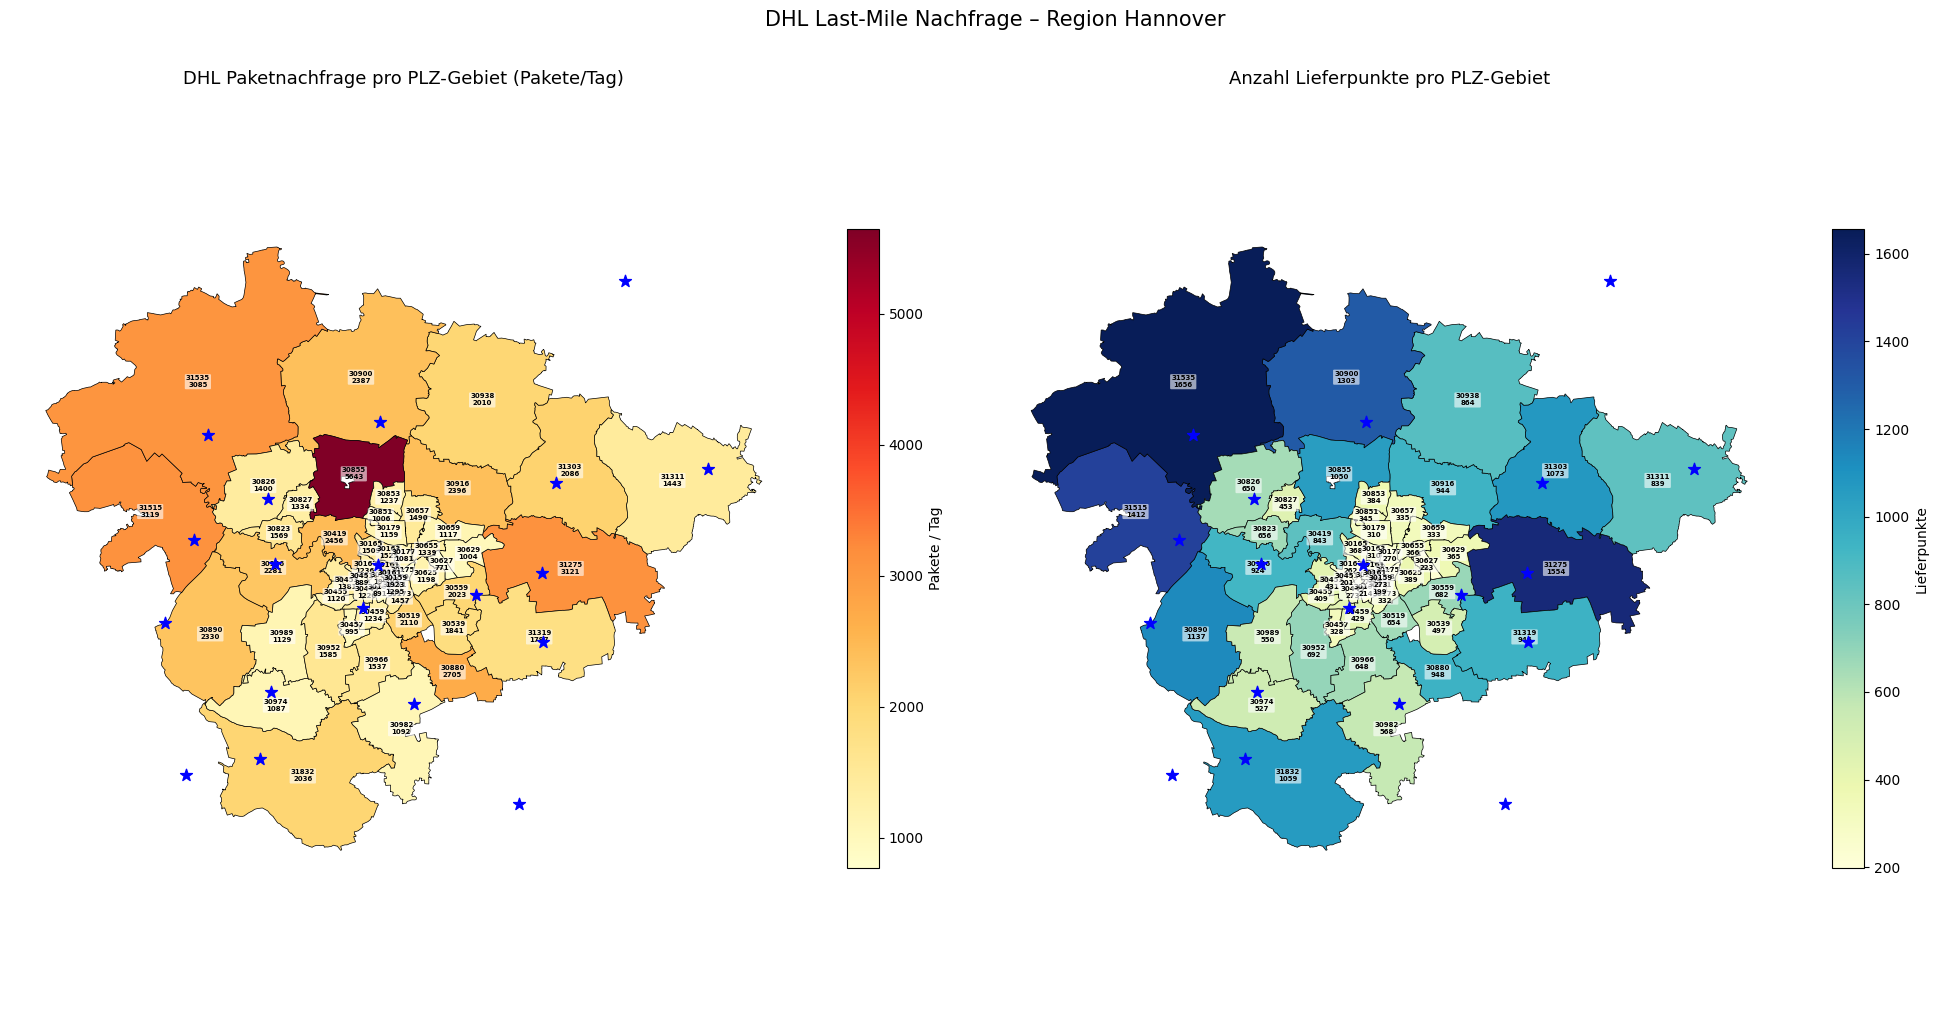

14:40:23 [INFO] Nachfragekarte: 53 PLZ-Gebiete, 90174 Pakete/Tag gesamt


In [37]:
# ── Karte: Paketnachfrage pro PLZ-Gebiet ─────────────────────────────────────
from matplotlib.colors import Normalize
from matplotlib import cm

# Merge PLZ polygons with demand stats (after small-PLZ merge)
gdf_demand_map = gdf_plz.merge(plz_stats, on='plz', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# ── (a) Parcels per day ──────────────────────────────────────────────────────
ax = axes[0]
norm_parcels = Normalize(vmin=gdf_demand_map['parcels_day'].min(),
                         vmax=gdf_demand_map['parcels_day'].max())
gdf_demand_map.plot(ax=ax, column='parcels_day', cmap='YlOrRd', edgecolor='black',
                    linewidth=0.5, legend=True,
                    legend_kwds={'label': 'Pakete / Tag', 'shrink': 0.7})
# Labels with PLZ + value
for _, row in gdf_demand_map.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(f'{row["plz"]}\n{int(row["parcels_day"])}',
                (cx, cy), fontsize=5, ha='center', va='center', fontweight='bold',
                color='black', bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.6, lw=0))
# Hubs
gdf_hubs.plot(ax=ax, color='blue', markersize=80, marker='*', zorder=10)
ax.set_title('DHL Paketnachfrage pro PLZ-Gebiet (Pakete/Tag)', fontsize=13)
ax.axis('equal')
ax.set_axis_off()

# ── (b) Number of delivery points ───────────────────────────────────────────
ax = axes[1]
gdf_demand_map.plot(ax=ax, column='n_points', cmap='YlGnBu', edgecolor='black',
                    linewidth=0.5, legend=True,
                    legend_kwds={'label': 'Lieferpunkte', 'shrink': 0.7})
for _, row in gdf_demand_map.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(f'{row["plz"]}\n{int(row["n_points"])}',
                (cx, cy), fontsize=5, ha='center', va='center', fontweight='bold',
                color='black', bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.6, lw=0))
gdf_hubs.plot(ax=ax, color='blue', markersize=80, marker='*', zorder=10)
ax.set_title('Anzahl Lieferpunkte pro PLZ-Gebiet', fontsize=13)
ax.axis('equal')
ax.set_axis_off()

plt.suptitle('DHL Last-Mile Nachfrage – Region Hannover', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

log.info(f'Nachfragekarte: {len(gdf_demand_map)} PLZ-Gebiete, '
         f'{gdf_demand_map["parcels_day"].sum():.0f} Pakete/Tag gesamt')

## 3 – Load DHL Hub Locations

In [23]:
# ── Load hub locations and filter for DHL / DP-DHL ───────────────────────────
hubs_csv = INPUT / 'hubs' / 'KEP-hubs_v3.csv'
df_hubs = pd.read_csv(hubs_csv, sep=';')
log.info(f'Total hubs loaded: {len(df_hubs)}')
print(f'Carriers: {df_hubs["Anbieter"].unique()}')

# Filter for DHL and DP/DHL hub types
dhl_mask = df_hubs['Anbieter'].str.contains('DHL', case=False, na=False)
df_dhl_hubs = df_hubs[dhl_mask].copy()
log.info(f'DHL hubs after filter: {len(df_dhl_hubs)}')

# Create GeoDataFrame (coordinates in EPSG:25832 – UTM zone 32N)
gdf_hubs = gpd.GeoDataFrame(
    df_dhl_hubs,
    geometry=gpd.points_from_xy(df_dhl_hubs['X'], df_dhl_hubs['Y']),
    crs='EPSG:25832'
)

# Compute WGS84 coordinates for VROOM (requires lon/lat)
gdf_hubs_wgs = gdf_hubs.to_crs(epsg=4326)
gdf_hubs['lon'] = gdf_hubs_wgs.geometry.x
gdf_hubs['lat'] = gdf_hubs_wgs.geometry.y

log.info('DHL hub locations:')
gdf_hubs[['Bezeichnun', 'Typ', 'Postleitzahl', 'Ort', 'lon', 'lat']]

13:23:57 [INFO] Total hubs loaded: 25
13:23:57 [INFO] DHL hubs after filter: 19
13:23:57 [INFO] DHL hub locations:


Carriers: <StringArray>
['DHL', 'DP/DHL', 'Hermes', 'Amazon', 'DPD', 'GLS', 'UPS', 'fedex']
Length: 8, dtype: str


,Bezeichnun,Typ,Postleitzahl,Ort,lon,lat
0,Paketzentrum / Zustellbasis Anderten,PZ/ZB,30559,Hannover_Anderten,9.875265,52.358945
1,Zustellbasis Hannover am Güterbahnhof,ZB,30167,Hannover_Güterbahnhof,9.730077,52.387042
2,Zustellbasis Hannover-Süd,ZB,30453,Hannover_Süd,9.708442,52.348763
3,Brief- und Logistikzentrum in Pattensen (Hanno...,BZ,30982,Pattensen,9.781330,52.260462
4,"Deutsche Post, Neustadt",ZSP,31535,Neustadt_am_Rübenberge,9.479659,52.506502
5,"Deutsche Post, Garbsen",ZSP,30826,Garbsen,9.568967,52.448200
11,"Deutsche Post, Bissendorf",ZSP,30900,Wedemark,9.736541,52.517111
12,Dummy Uetze,ZSP,0,Uetze,10.223560,52.470151
13,"Deutsche Post, Burgdorf",ZSP,31303,Burgdorf,9.997203,52.459993
14,"Deutsche Post, Lehrte",ZSP,31275,Lehrte,9.974242,52.377958


## 4 – Parse Vehicle Types from XML (ct_cep_size_l, capacity 230)

In [24]:
# ── Parse MATSim vehicle type definitions from XML ──────────────────────────
# Source: HAGRID project vehicle fleet definitions (MATSim v2.0 format)
vehicle_xml = INPUT / 'vehicles' / 'HAGRID_vehicleTypes2.0.xml'
tree = ET.parse(vehicle_xml)
root_xml = tree.getroot()

# XML namespace for MATSim vehicle definitions
ns = {'m': 'http://www.matsim.org/files/dtd'}

vehicle_types = {}
for vt in root_xml.findall('.//m:vehicleType', ns):
    vid = vt.get('id')
    cap_el = vt.find('m:capacity', ns)
    cost_el = vt.find('m:costInformation', ns)
    vel_el = vt.find('m:maximumVelocity', ns)
    
    capacity = float(cap_el.get('other', 0)) if cap_el is not None else 0
    fixed_cost = float(cost_el.get('fixedCostsPerDay', 0)) if cost_el is not None else 0
    cost_per_m = float(cost_el.get('costsPerMeter', 0)) if cost_el is not None else 0
    cost_per_s = float(cost_el.get('costsPerSecond', 0)) if cost_el is not None else 0
    max_vel = float(vel_el.get('meterPerSecond', 0)) if vel_el is not None else 0
    
    # Extract waiting cost from nested attributes
    cost_waiting = 0
    if cost_el is not None:
        for attr in cost_el.findall('.//m:attribute', ns):
            if attr.get('name') == 'costsPerSecondWaiting':
                cost_waiting = float(attr.text)
    
    vehicle_types[vid] = {
        'capacity': int(capacity),
        'fixed_cost_per_day': fixed_cost,
        'cost_per_meter': cost_per_m,
        'cost_per_second': cost_per_s,
        'cost_per_second_waiting': cost_waiting,
        'max_velocity_ms': max_vel,
        'max_velocity_kmh': round(max_vel * 3.6, 1),
    }

log.info(f'{len(vehicle_types)} vehicle types parsed from XML')
for vid, info in vehicle_types.items():
    print(f'  {vid}: capacity={info["capacity"]}, fixed={info["fixed_cost_per_day"]} EUR/day, '
          f'cost/m={info["cost_per_meter"]}, v_max={info["max_velocity_kmh"]} km/h')

# Selected vehicle type for DHL CEP: ct_cep_size_l (large delivery van, 230 parcels)
DHL_VEHICLE_TYPE = 'ct_cep_size_l'
vt = vehicle_types[DHL_VEHICLE_TYPE]
log.info(f'Selected vehicle type: {DHL_VEHICLE_TYPE}')
print(f'  Capacity:    {vt["capacity"]} parcels')
print(f'  Fixed cost:  {vt["fixed_cost_per_day"]} EUR/day')
print(f'  Cost/km:     {vt["cost_per_meter"] * 1000:.4f} EUR/km')
print(f'  Cost/s:      {vt["cost_per_second"]} EUR/s')
print(f'  Max speed:   {vt["max_velocity_kmh"]} km/h')

13:24:02 [INFO] 12 vehicle types parsed from XML
13:24:02 [INFO] Selected vehicle type: ct_cep_size_l


  ct_bus: capacity=50, fixed=160.0 EUR/day, cost/m=0.00077, v_max=100.0 km/h
  ct_car: capacity=5, fixed=38.8 EUR/day, cost/m=0.000370807, v_max=200.0 km/h
  ct_cep_bike: capacity=23, fixed=137.39 EUR/day, cost/m=0.0, v_max=15.0 km/h
  ct_cep_size_l: capacity=230, fixed=189.15 EUR/day, cost/m=0.000386430173292559, v_max=140.0 km/h
  ct_cep_size_m: capacity=165, fixed=171.78 EUR/day, cost/m=0.000371826707441386, v_max=160.0 km/h
  ct_egrocery_bike: capacity=5, fixed=137.39 EUR/day, cost/m=0.0, v_max=15.0 km/h
  ct_egrocery_van: capacity=18, fixed=189.59 EUR/day, cost/m=0.000123, v_max=0.0 km/h
  ct_motorbike: capacity=1, fixed=50.0 EUR/day, cost/m=0.00023, v_max=160.0 km/h
  ct_other: capacity=5, fixed=80.0 EUR/day, cost/m=0.00047, v_max=160.0 km/h
  ct_truck_heavy: capacity=2000, fixed=618.55 EUR/day, cost/m=0.000555126, v_max=80.0 km/h
  ct_truck_light: capacity=1000, fixed=550.63 EUR/day, cost/m=0.000486430173292559, v_max=80.0 km/h
  ct_truck_super_light: capacity=230, fixed=189.15 

## 5 – Assign Postal Codes to Nearest DHL Hub

In [66]:
# ── Assign each postal code to its nearest DHL hub (size-weighted) ────────────
# Compute PLZ area centroids in EPSG:25832 (metric CRS for accurate distances)
plz_centroids = gdf_plz[['plz', 'geometry']].copy()
plz_centroids['centroid'] = plz_centroids.geometry.centroid

# Only consider postal codes that have DHL demand
plz_with_demand = set(gdf_dhl['plz'].unique())
plz_centroids = plz_centroids[plz_centroids['plz'].isin(plz_with_demand)].copy()
log.info(f'{len(plz_centroids)} postal codes with DHL demand')

# Find nearest hub for each PLZ using SIZE-WEIGHTED distance
# Grosse Hubs (ZB, PZ/ZB, BZ) werden bevorzugt: Distanz zu kleinen Hubs (ZSP)
# wird mit SMALL_HUB_DISTANCE_PENALTY multipliziert.
hub_coords = np.array([(g.x, g.y) for g in gdf_hubs.geometry])
hub_types = list(gdf_hubs['Typ'])
hub_indices = list(gdf_hubs.index)

assignments = []
for _, row in plz_centroids.iterrows():
    cx, cy = row['centroid'].x, row['centroid'].y
    real_dists = np.sqrt((hub_coords[:, 0] - cx)**2 + (hub_coords[:, 1] - cy)**2)
    
    # Apply penalty to small hubs -> large hubs preferred
    weighted_dists = real_dists.copy()
    for i, ht in enumerate(hub_types):
        if ht not in LARGE_HUB_TYPES:
            weighted_dists[i] *= SMALL_HUB_DISTANCE_PENALTY
    
    nearest_idx = np.argmin(weighted_dists)
    nearest_hub_row = gdf_hubs.iloc[nearest_idx]
    assignments.append({
        'plz': row['plz'],
        'hub_name': nearest_hub_row['Bezeichnun'],
        'hub_typ': nearest_hub_row['Typ'],
        'hub_lon': nearest_hub_row['lon'],
        'hub_lat': nearest_hub_row['lat'],
        'hub_x': nearest_hub_row['X'],
        'hub_y': nearest_hub_row['Y'],
        'dist_km': round(real_dists[nearest_idx] / 1000, 2),
        'weighted_dist_km': round(weighted_dists[nearest_idx] / 1000, 2),
    })

df_assignments = pd.DataFrame(assignments)

# Show assignment summary with hub type info
log.info('Hub-Zuweisung mit Groessenpreferenz (grosse Hubs bevorzugt):')
hub_summary = df_assignments.groupby(['hub_name', 'hub_typ'])['plz'].count().reset_index()
hub_summary.columns = ['Hub', 'Typ', 'PLZ-Gebiete']
hub_summary = hub_summary.sort_values('PLZ-Gebiete', ascending=False)
for _, r in hub_summary.iterrows():
    marker = '*' if r['Typ'] in LARGE_HUB_TYPES else '.'
    print(f'  {marker} {r["Hub"]:<45} ({r["Typ"]:>5})  -> {r["PLZ-Gebiete"]} PLZ')

n_large = df_assignments[df_assignments['hub_typ'].isin(LARGE_HUB_TYPES)].shape[0]
n_small = df_assignments[~df_assignments['hub_typ'].isin(LARGE_HUB_TYPES)].shape[0]
log.info(f'Grosse Hubs: {n_large} PLZ  |  Kleine Hubs (ZSP): {n_small} PLZ')
log.info(f'Avg Distanz: {df_assignments["dist_km"].mean():.1f} km (real)  |  {df_assignments["weighted_dist_km"].mean():.1f} km (gewichtet)')
df_assignments

16:24:52 [INFO] 53 postal codes with DHL demand
16:24:52 [INFO] Hub-Zuweisung mit Groessenpreferenz (grosse Hubs bevorzugt):
16:24:52 [INFO] Grosse Hubs: 36 PLZ  |  Kleine Hubs (ZSP): 17 PLZ
16:24:52 [INFO] Avg Distanz: 3.8 km (real)  |  4.4 km (gewichtet)


  * Zustellbasis Hannover am Güterbahnhof         (   ZB)  -> 18 PLZ
  * Zustellbasis Hannover-Süd                     (   ZB)  -> 9 PLZ
  * Paketzentrum / Zustellbasis Anderten          (PZ/ZB)  -> 6 PLZ
  * Brief- und Logistikzentrum in Pattensen (Hannover) (   BZ)  -> 3 PLZ
  . Deutsche Post, Bissendorf                     (  ZSP)  -> 3 PLZ
  . Dummy Seelze                                  (  ZSP)  -> 2 PLZ
  . Deutsche Post, Garbsen                        (  ZSP)  -> 2 PLZ
  . Dummy Wennigsen                               (  ZSP)  -> 2 PLZ
  . Deutsche Post, Springe                        (  ZSP)  -> 1 PLZ
  . Deutsche Post, Neustadt                       (  ZSP)  -> 1 PLZ
  . Deutsche Post, Lehrte                         (  ZSP)  -> 1 PLZ
  . Deutsche Post, Burgdorf                       (  ZSP)  -> 1 PLZ
  . Deutsche Post, Bantorf                        (  ZSP)  -> 1 PLZ
  . Dummy Uetze                                   (  ZSP)  -> 1 PLZ
  . Deutsche Post, Wunstorf               

,plz,hub_name,hub_typ,hub_lon,hub_lat,hub_x,hub_y,dist_km,weighted_dist_km
0,31515,"Deutsche Post, Wunstorf",ZSP,9.457973,52.411535,531150.880000,5.806911e+06,5.28,7.92
1,30890,"Deutsche Post, Bantorf",ZSP,9.413741,52.336366,528190.077000,5.798531e+06,4.73,7.10
2,31832,"Deutsche Post, Springe",ZSP,9.553321,52.211795,537806.100000,5.784739e+06,4.65,6.97
3,30974,Dummy Wennigsen,ZSP,9.570711,52.272664,538940.996000,5.791519e+06,1.40,2.10
4,30926,Dummy Seelze,ZSP,9.578454,52.388586,539366.230000,5.804417e+06,0.37,0.56
5,30989,Dummy Wennigsen,ZSP,9.570711,52.272664,538940.996000,5.791519e+06,5.72,8.59
6,30916,Paketzentrum / Zustellbasis Anderten,PZ/ZB,9.875265,52.358945,559605.059550,5.801323e+06,11.00,11.00
7,30938,"Deutsche Post, Bissendorf",ZSP,9.736541,52.517111,549978.890000,5.818810e+06,10.53,15.79
8,31275,"Deutsche Post, Lehrte",ZSP,9.974242,52.377958,566316.700000,5.803524e+06,2.93,4.40
9,31303,"Deutsche Post, Burgdorf",ZSP,9.997203,52.459993,567753.770000,5.812669e+06,1.84,2.76


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_41064\3974974179.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left', fontsize=7)


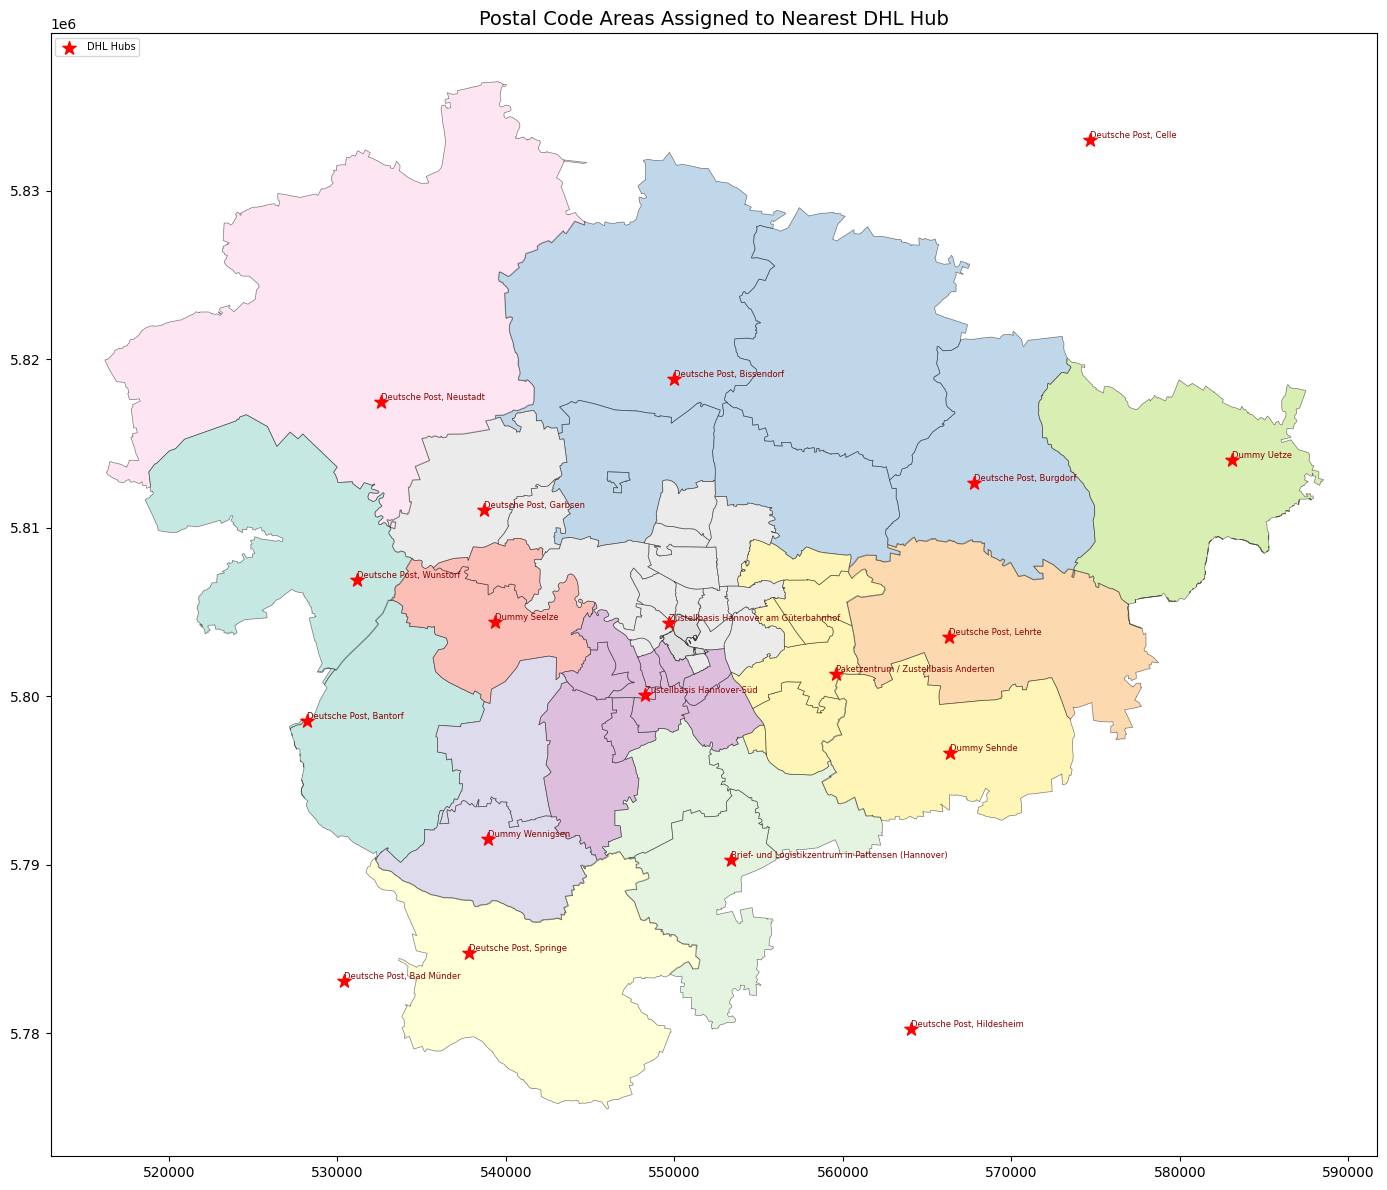

In [10]:
# ── Map: postal code areas colored by assigned hub ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))

# Merge PLZ areas with hub assignments
gdf_plz_assigned = gdf_plz.merge(df_assignments[['plz', 'hub_name', 'dist_km']], on='plz', how='inner')

# Color each postal code area by its assigned hub
hub_names = gdf_plz_assigned['hub_name'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(hub_names)))
hub_color_map = dict(zip(hub_names, colors))

for hub_name, group in gdf_plz_assigned.groupby('hub_name'):
    group.plot(ax=ax, color=hub_color_map[hub_name], edgecolor='black',
              linewidth=0.5, alpha=0.5, label=hub_name)

# Plot hub locations
gdf_hubs.plot(ax=ax, color='red', markersize=100, marker='*', zorder=10, label='DHL Hubs')
for _, hub in gdf_hubs.iterrows():
    ax.annotate(hub['Bezeichnun'], (hub.geometry.x, hub.geometry.y),
               fontsize=6, ha='left', va='bottom', color='darkred')

ax.legend(loc='upper left', fontsize=7)
ax.set_title('Postal Code Areas Assigned to Nearest DHL Hub', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

## 6 – Build VROOM VRP Request per Postal Code

In [65]:
# ── VROOM VRP configuration ──────────────────────────────────────────────────
VEHICLE_CAPACITY = vt['capacity']          # 230 parcels (from XML ct_cep_size_l)
FIXED_COST = int(vt['fixed_cost_per_day']) # 189 EUR/day (VROOM fixed cost)
# VROOM costs require integers → scale to euro-cents (factor 100)
COST_SCALE = 100
COST_PER_KM_EUR = round(vt['cost_per_meter'] * 1000, 4)   # 0.3864 EUR/km
COST_PER_HOUR_EUR = round(vt['cost_per_second'] * 3600, 2) # 0.0 EUR/h
FIXED_COST_CENTS = int(round(vt['fixed_cost_per_day'] * COST_SCALE))  # VROOM integer
COST_PER_KM_CENTS = int(round(COST_PER_KM_EUR * COST_SCALE))          # VROOM integer
COST_PER_HOUR_CENTS = int(round(COST_PER_HOUR_EUR * COST_SCALE))      # VROOM integer

SERVICE_TIME_PER_PARCEL = 120               # seconds per PARCEL (not per stop)
SERVICE_TIME_CAP = 900                     # max 15 min (900s) per stop
PROFILE = 'auto'                           # Valhalla routing profile
VROOM_API_URL = 'http://localhost:3000'     # VROOM API endpoint

# ── Zeitfenster: Fahrzeug vs. Lieferung ──────────────────────────────────────
# Fahrzeuge dürfen VOR und NACH dem Lieferzeitfenster zur An-/Rückfahrt zum Hub fahren.
# → Fahrzeug-Zeitfenster ist breiter als das Lieferzeitfenster der Jobs.
COMMUTE_BUFFER = 3600                      # 1 Stunde Puffer für An-/Rückfahrt
DELIVERY_WINDOW = [28800, 72000]           # 08:00 – 20:00  (Jobs: erlaubte Lieferzeit)
VEHICLE_TIME_WINDOW = [                    # 07:00 – 21:00  (Fahrzeuge: inkl. Anfahrt/Rückfahrt)
    DELIVERY_WINDOW[0] - COMMUTE_BUFFER,   # 07:00 = 25200
    DELIVERY_WINDOW[1] + COMMUTE_BUFFER,   # 21:00 = 75600
]

# ── Stundenabhängige Verkehrsfaktoren (Tagesganglinie 0–24 Uhr) ──────────────
TRAFFIC_FACTORS = {
    0: 1.00,  1: 1.00,  2: 1.00,  3: 1.00,  4: 1.00,  5: 1.00,
    6: 1.05,  # früher Berufsverkehr
    7: 1.25,  # Morgenspitze aufbauend
    8: 1.35,  # Morgenspitze Höhepunkt
    9: 1.20,  # abklingend
    10: 1.05, 11: 1.05,
    12: 1.10, 13: 1.10, 14: 1.10,  # Mittagsverkehr
    15: 1.20, # Nachmittagsspitze aufbauend
    16: 1.30, # Abendspitze
    17: 1.35, # Abendspitze Höhepunkt
    18: 1.20, # abklingend
    19: 1.05, 20: 1.00, 21: 1.00, 22: 1.00, 23: 1.00,
}

# Gewichteter Durchschnittsfaktor über das FAHRZEUG-Zeitfenster (inkl. Anfahrt)
_veh_start_h = VEHICLE_TIME_WINDOW[0] // 3600   # 7
_veh_end_h = min(VEHICLE_TIME_WINDOW[1] // 3600, 23)  # 21
_window_factors = [TRAFFIC_FACTORS[h] for h in range(_veh_start_h, _veh_end_h)]
AVG_TRAFFIC_FACTOR = round(sum(_window_factors) / len(_window_factors), 4)

# VROOM speed_factor: Skaliert ALLE Reisezeiten des Fahrzeugs.
#   speed_factor < 1 → Fahrzeug ist langsamer → Reisezeiten werden länger
#   Effektive Reisezeit = Basis-Reisezeit / speed_factor
SPEED_FACTOR = round(1.0 / AVG_TRAFFIC_FACTOR, 3)

# ── Hub-Größenpräferenz: Große Zustellbasen bevorzugen ────────────────────────
# Hub-Typen: ZB / PZ/ZB / BZ = große Hubs (direkt beliefert, früher Start)
#            ZSP = kleine Zustellstützpunkte (werden erst angeliefert → späterer Start)
LARGE_HUB_TYPES = {'ZB', 'PZ/ZB', 'BZ'}   # Zustellbasen, Paketzentren, Briefzentren
SMALL_HUB_TYPE  = 'ZSP'                    # Zustellstützpunkte (Deutsche Post)

# Entfernungs-Strafaktor für kleine Hubs: effektive Distanz = reale × Faktor
# → Ein großer Hub wird bevorzugt, auch wenn er etwas weiter weg ist
SMALL_HUB_DISTANCE_PENALTY = 1.5   # ZSP muss 33% näher sein um gewählt zu werden

# Fahrzeuge an kleinen Hubs (ZSP) starten 1h später, weil erst Zustellung nötig
SMALL_HUB_DELAY = 3600  # 1 Stunde Verzögerung für ZSP-Hubs

# ── Parallelization & performance settings ───────────────────────────────────
PARALLEL_WORKERS = 3    # concurrent VROOM solve requests
HTTP_TIMEOUT = 1800     # 30 min per request (large PLZs need 10-20 min)
MAX_RETRIES = 10        # max retries per PLZ for unfound routes
CONNECTION_RETRIES = 2  # max retries on connection errors

log.info('Vehicle configuration:')
print(f'  Capacity:       {VEHICLE_CAPACITY} parcels')
print(f'  Fixed cost:     {vt["fixed_cost_per_day"]} EUR/day  (VROOM: {FIXED_COST_CENTS} cents)')
print(f'  Cost/km:        {COST_PER_KM_EUR} EUR/km  (VROOM: {COST_PER_KM_CENTS} cents/km)')
print(f'  Cost/h:         {COST_PER_HOUR_EUR} EUR/h  (VROOM: {COST_PER_HOUR_CENTS} cents/h)')
print(f'  Service/Paket:  {SERVICE_TIME_PER_PARCEL}s x Anzahl Pakete  (max {SERVICE_TIME_CAP}s = {SERVICE_TIME_CAP//60} min/Stopp)')
print(f'  Profile:        {PROFILE}')
print(f'  VROOM API:      {VROOM_API_URL}')
print()
print('── Zeitfenster ──')
print(f'  Fahrzeug:       {VEHICLE_TIME_WINDOW[0]//3600}:00 - {VEHICLE_TIME_WINDOW[1]//3600}:00  (inkl. {COMMUTE_BUFFER//60} min An-/Rueckfahrt)')
print(f'  Lieferung:      {DELIVERY_WINDOW[0]//3600}:00 - {DELIVERY_WINDOW[1]//3600}:00  (Job-Zeitfenster)')
print()
print('── Hub-Groessenpreferenz ──')
print(f'  Grosse Hub-Typen:      {LARGE_HUB_TYPES}')
print(f'  Klein (ZSP) Penalty:   x{SMALL_HUB_DISTANCE_PENALTY}  (Distanz-Strafaktor)')
print(f'  ZSP Start-Verzoegerung: +{SMALL_HUB_DELAY//60} min  (Fahrzeuge starten spaeter)')
print()
print('── Verkehrsfaktoren (Tagesganglinie) ──')
for h in range(_veh_start_h, _veh_end_h):
    bar = '|' * int(TRAFFIC_FACTORS[h] * 20)
    print(f'  {h:02d}:00  x{TRAFFIC_FACTORS[h]:.2f}  {bar}')
print(f'  Avg Faktor ({_veh_start_h}:00-{_veh_end_h}:00):  x{AVG_TRAFFIC_FACTOR:.4f}')
print(f'  VROOM speed_factor:       {SPEED_FACTOR}')
print(f'  Reisezeiten werden um {(AVG_TRAFFIC_FACTOR - 1) * 100:.1f}% verlaengert')
print()
print(f'  Parallel:       {PARALLEL_WORKERS} workers')
print(f'  HTTP timeout:   {HTTP_TIMEOUT}s')

16:24:42 [INFO] Vehicle configuration:


  Capacity:       230 parcels
  Fixed cost:     189.15 EUR/day  (VROOM: 18915 cents)
  Cost/km:        0.3864 EUR/km  (VROOM: 39 cents/km)
  Cost/h:         0.0 EUR/h  (VROOM: 0 cents/h)
  Service/Paket:  120s x Anzahl Pakete  (max 900s = 15 min/Stopp)
  Profile:        auto
  VROOM API:      http://localhost:3000

── Zeitfenster ──
  Fahrzeug:       7:00 - 21:00  (inkl. 60 min An-/Rueckfahrt)
  Lieferung:      8:00 - 20:00  (Job-Zeitfenster)

── Hub-Groessenpreferenz ──
  Grosse Hub-Typen:      {'BZ', 'ZB', 'PZ/ZB'}
  Klein (ZSP) Penalty:   x1.5  (Distanz-Strafaktor)
  ZSP Start-Verzoegerung: +60 min  (Fahrzeuge starten spaeter)

── Verkehrsfaktoren (Tagesganglinie) ──
  07:00  x1.25  |||||||||||||||||||||||||
  08:00  x1.35  |||||||||||||||||||||||||||
  09:00  x1.20  ||||||||||||||||||||||||
  10:00  x1.05  |||||||||||||||||||||
  11:00  x1.05  |||||||||||||||||||||
  12:00  x1.10  ||||||||||||||||||||||
  13:00  x1.10  ||||||||||||||||||||||
  14:00  x1.10  ||||||||||||||||||||||
 

In [67]:
# ── Reproject demand points to WGS84 (lon/lat for VROOM) ─────────────────────
if gdf_dhl.crs and gdf_dhl.crs.to_epsg() != 4326:
    gdf_dhl_wgs = gdf_dhl.to_crs(epsg=4326)
else:
    gdf_dhl_wgs = gdf_dhl.copy()

# Extract longitude and latitude for VROOM location format [lon, lat]
# Use centroid to handle any non-point geometries from spatial join
gdf_dhl_wgs['lon'] = gdf_dhl_wgs.geometry.centroid.x
gdf_dhl_wgs['lat'] = gdf_dhl_wgs.geometry.centroid.y
log.info(f'{len(gdf_dhl_wgs)} DHL demand points reprojected to WGS84')
gdf_dhl_wgs[['plz', 'dhl_tag', 'lon', 'lat']].head()

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25908\1501662319.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_dhl_wgs['lon'] = gdf_dhl_wgs.geometry.centroid.x
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25908\1501662319.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_dhl_wgs['lat'] = gdf_dhl_wgs.geometry.centroid.y
16:25:03 [INFO] 31017 DHL demand points reprojected to WGS84


,plz,dhl_tag,lon,lat
0,30890,5,9.417857,52.334498
1,30890,2,9.417857,52.334498
2,31515,1,9.353873,52.443825
4,31515,2,9.386010,52.457410
6,30890,7,9.419005,52.333802


In [68]:
# ── Build VROOM VRP requests for each postal code ───────────────────────────
# Optimizations vs. previous version:
# 1) No MAX_VEHICLES_PER_PLZ cap – vehicles computed dynamically per demand
# 2) Oversized jobs (amount > capacity) split at build time, not post-hoc
# 3) Pre-sort by problem size (largest first) for better parallel utilization
# 4) Separate time windows: Fahrzeug (inkl. Anfahrt) vs. Job (Lieferung)
# 5) speed_factor für Verkehrskorrektur auf Fahrzeuge angewendet

vroom_requests = {}  # plz -> vroom request dict
summary_rows = []
oversized_splits = 0

for plz_code in sorted(gdf_dhl_wgs['plz'].unique()):
    plz_points = gdf_dhl_wgs[gdf_dhl_wgs['plz'] == plz_code].copy()
    if len(plz_points) == 0:
        continue
    
    hub_row = df_assignments[df_assignments['plz'] == plz_code]
    if len(hub_row) == 0:
        log.warning(f'No hub assigned for PLZ {plz_code} – skipping')
        continue
    hub = hub_row.iloc[0]
    hub_lon, hub_lat = hub['hub_lon'], hub['hub_lat']
    
    # Build job list – split oversized jobs immediately
    # Jobs bekommen DELIVERY_WINDOW als time_window (Lieferungen nur 08:00-20:00)
    jobs = []
    total_demand = 0
    for _, row in plz_points.iterrows():
        amount = int(row['dhl_tag'])
        total_demand += amount
        loc = [round(row['lon'], 6), round(row['lat'], 6)]
        
        if amount > VEHICLE_CAPACITY:
            # Split into capacity-sized chunks at same location
            remaining = amount
            while remaining > 0:
                chunk = min(remaining, VEHICLE_CAPACITY)
                svc = min(chunk * SERVICE_TIME_PER_PARCEL, SERVICE_TIME_CAP)
                jobs.append({
                    'id': len(jobs) + 1,
                    'location': loc,
                    'service': svc,
                    'amount': [chunk],
                    'time_windows': [DELIVERY_WINDOW],  # Lieferung nur 08:00-20:00
                })
                remaining -= chunk
            oversized_splits += 1
        else:
            svc = min(amount * SERVICE_TIME_PER_PARCEL, SERVICE_TIME_CAP)
            jobs.append({
                'id': len(jobs) + 1,
                'location': loc,
                'service': svc,
                'amount': [amount],
                'time_windows': [DELIVERY_WINDOW],  # Lieferung nur 08:00-20:00
            })
    
    # Dynamic fleet size: no cap – just ceil(demand / capacity)
    n_vehicles = max(1, math.ceil(total_demand / VEHICLE_CAPACITY))
    
    # Fahrzeuge bekommen VEHICLE_TIME_WINDOW (breiter: inkl. An-/Rückfahrt)
    # Bei kleinen Hubs (ZSP): +1h Verzögerung (erst Anlieferung nötig)
    hub_typ = hub['hub_typ']
    is_small_hub = hub_typ not in LARGE_HUB_TYPES
    if is_small_hub:
        veh_tw = [VEHICLE_TIME_WINDOW[0] + SMALL_HUB_DELAY, VEHICLE_TIME_WINDOW[1]]
    else:
        veh_tw = VEHICLE_TIME_WINDOW
    
    vehicles = []
    for vid in range(1, n_vehicles + 1):
        vehicle = {
            'id': vid,
            'profile': PROFILE,
            'start': [round(hub_lon, 6), round(hub_lat, 6)],
            'end': [round(hub_lon, 6), round(hub_lat, 6)],
            'capacity': [VEHICLE_CAPACITY],
            'time_window': veh_tw,                    # 07:00 (groß) oder 08:00 (ZSP)
            'speed_factor': SPEED_FACTOR,             # Verkehrskorrektur
        }
        costs = {'fixed': FIXED_COST_CENTS}
        if COST_PER_KM_CENTS > 0:
            costs['per_km'] = COST_PER_KM_CENTS
        if COST_PER_HOUR_CENTS > 0:
            costs['per_hour'] = COST_PER_HOUR_CENTS
        vehicle['costs'] = costs
        vehicles.append(vehicle)
    
    vroom_requests[plz_code] = {'vehicles': vehicles, 'jobs': jobs}
    
    summary_rows.append({
        'plz': plz_code,
        'hub': hub['hub_name'],
        'hub_typ': hub_typ,
        'is_small_hub': is_small_hub,
        'n_jobs': len(jobs),
        'total_parcels': total_demand,
        'n_vehicles': n_vehicles,
        'hub_dist_km': hub['dist_km'],
        'veh_start_h': veh_tw[0] // 3600,
    })

df_summary = pd.DataFrame(summary_rows)
log.info(f'{len(vroom_requests)} VRP requests built')
log.info(f'Total: {df_summary["n_jobs"].sum()} jobs, '
         f'{df_summary["total_parcels"].sum()} parcels, '
         f'{df_summary["n_vehicles"].sum()} vehicles')

n_large_hub_plz = (~df_summary['is_small_hub']).sum()
n_small_hub_plz = df_summary['is_small_hub'].sum()
log.info(f'Grosse Hubs: {n_large_hub_plz} PLZ (Start 07:00)  |  Kleine Hubs (ZSP): {n_small_hub_plz} PLZ (Start 08:00)')
log.info(f'Speed factor: {SPEED_FACTOR} (Avg Verkehr x{AVG_TRAFFIC_FACTOR})')
if oversized_splits > 0:
    log.info(f'Oversized jobs pre-split: {oversized_splits}')
df_summary.sort_values('total_parcels', ascending=False)

16:25:13 [WARNING] No hub assigned for PLZ 00000 – skipping
16:25:14 [INFO] 51 VRP requests built
16:25:14 [INFO] Total: 31011 jobs, 86350 parcels, 400 vehicles
16:25:14 [INFO] Grosse Hubs: 34 PLZ (Start 07:00)  |  Kleine Hubs (ZSP): 17 PLZ (Start 08:00)
16:25:14 [INFO] Speed factor: 0.859 (Avg Verkehr x1.1643)
16:25:14 [INFO] Oversized jobs pre-split: 1


,plz,hub,hub_typ,is_small_hub,n_jobs,total_parcels,n_vehicles,hub_dist_km,veh_start_h
32,30855,"Deutsche Post, Bissendorf",ZSP,True,1050,5643,25,5.89,8
44,31275,"Deutsche Post, Lehrte",ZSP,True,1554,3121,14,2.93,8
48,31515,"Deutsche Post, Wunstorf",ZSP,True,1412,3119,14,5.28,8
49,31535,"Deutsche Post, Neustadt",ZSP,True,1656,3085,14,5.50,8
33,30880,Brief- und Logistikzentrum in Pattensen (Hanno...,BZ,False,948,2705,12,5.11,7
11,30419,Zustellbasis Hannover am Güterbahnhof,ZB,False,843,2456,11,5.16,7
36,30916,Paketzentrum / Zustellbasis Anderten,PZ/ZB,False,944,2396,11,11.00,7
35,30900,"Deutsche Post, Bissendorf",ZSP,True,1303,2387,11,4.94,8
34,30890,"Deutsche Post, Bantorf",ZSP,True,1137,2330,11,4.73,8
37,30926,Dummy Seelze,ZSP,True,924,2281,10,0.37,8


## 7 – Save VROOM Requests

In [69]:
# ── Save each VRP request as individual JSON file ────────────────────────────
for plz_code, request in vroom_requests.items():
    out_path = OUT_DIR / f'vroom_dhl_{plz_code}.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(request, f, ensure_ascii=False, indent=2)

# Save combined archive of all requests
combined_path = OUT_DIR / 'all_plz_requests.json'
with open(combined_path, 'w', encoding='utf-8') as f:
    json.dump(vroom_requests, f, ensure_ascii=False, indent=2)

# Save summary table as CSV
summary_path = OUT_DIR / 'vrp_summary.csv'
df_summary.to_csv(summary_path, index=False)

log.info(f'{len(vroom_requests)} JSON files saved to: {OUT_DIR}')
log.info(f'Combined archive: {combined_path}')
log.info(f'Summary CSV: {summary_path}')

# Show example request for the highest-demand postal code
example_plz = df_summary.sort_values('total_parcels', ascending=False).iloc[0]['plz']
print(f'\nExample request for PLZ {example_plz}:')
print(json.dumps(vroom_requests[example_plz], indent=2, ensure_ascii=False)[:2000])

16:25:26 [INFO] 51 JSON files saved to: c:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\requests\dhl_per_plz
16:25:26 [INFO] Combined archive: c:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\requests\dhl_per_plz\all_plz_requests.json
16:25:26 [INFO] Summary CSV: c:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\requests\dhl_per_plz\vrp_summary.csv



Example request for PLZ 30855:
{
  "vehicles": [
    {
      "id": 1,
      "profile": "auto",
      "start": [
        9.736541,
        52.517111
      ],
      "end": [
        9.736541,
        52.517111
      ],
      "capacity": [
        230
      ],
      "time_window": [
        28800,
        75600
      ],
      "speed_factor": 0.859,
      "costs": {
        "fixed": 18915,
        "per_km": 39
      }
    },
    {
      "id": 2,
      "profile": "auto",
      "start": [
        9.736541,
        52.517111
      ],
      "end": [
        9.736541,
        52.517111
      ],
      "capacity": [
        230
      ],
      "time_window": [
        28800,
        75600
      ],
      "speed_factor": 0.859,
      "costs": {
        "fixed": 18915,
        "per_km": 39
      }
    },
    {
      "id": 3,
      "profile": "auto",
      "start": [
        9.736541,
        52.517111
      ],
      "end": [
        9.736541,
        52.517111
      ],
      "capacity": [
        23

14:47:36 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:47:36 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


14:47:36 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:47:36 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


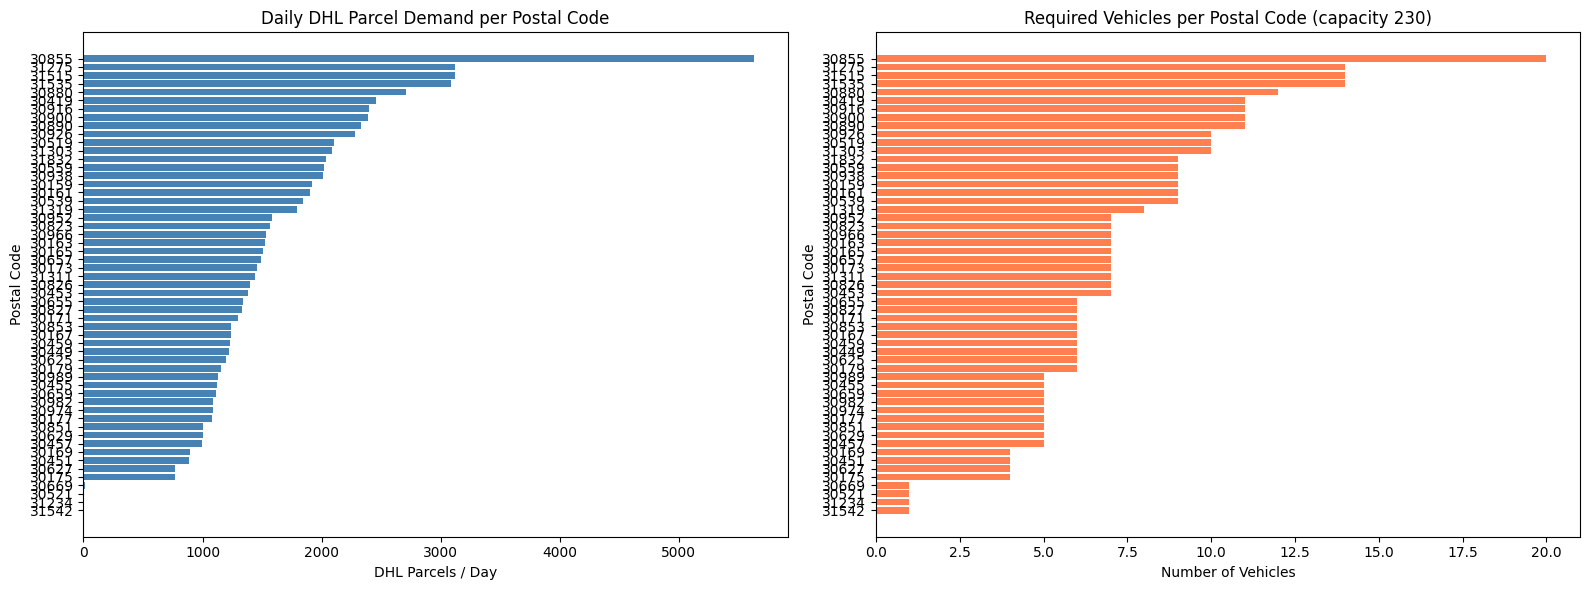

In [15]:
# ── Overview: parcels and vehicles per postal code ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot = df_summary.sort_values('total_parcels', ascending=True)

axes[0].barh(df_plot['plz'], df_plot['total_parcels'], color='steelblue')
axes[0].set_xlabel('DHL Parcels / Day')
axes[0].set_ylabel('Postal Code')
axes[0].set_title('Daily DHL Parcel Demand per Postal Code')

axes[1].barh(df_plot['plz'], df_plot['n_vehicles'], color='coral')
axes[1].set_xlabel('Number of Vehicles')
axes[1].set_ylabel('Postal Code')
axes[1].set_title(f'Required Vehicles per Postal Code (capacity {VEHICLE_CAPACITY})')

plt.tight_layout()
plt.show()

## 7b – Pre-validate Routability via Valhalla

Check every unique job location against Valhalla's `/locate` endpoint before sending to VROOM.
Locations that cannot snap to the road network (even with the configured snapping radius) are removed
from the VROOM requests to prevent "Unfound route" errors.

**Root causes addressed:**
- `loki.service_defaults.radius` was `0` → increased to `50 m` in `valhalla.json`
- `service_limits.auto.max_locations` was `20` → increased to `5000` in `valhalla.json`
- Remaining unroutable points are filtered here (e.g. park/forest/water locations)

In [70]:
# ── Pre-validation SKIPPED for performance ───────────────────────────────────
# Previous run showed 0 unroutable jobs out of 31,010.
# The matrix pre-validation took ~66 minutes – skipping saves significant time.
# Any routing issues are handled by the retry logic in the solve loop.
log.info('Pre-validation SKIPPED (0 unroutable in previous run, saves ~66 min)')
log.info(f'Proceeding directly to solve with {len(vroom_requests)} PLZ requests')

16:25:36 [INFO] Pre-validation SKIPPED (0 unroutable in previous run, saves ~66 min)
16:25:36 [INFO] Proceeding directly to solve with 51 PLZ requests


In [71]:
# ── Quick health check before parallel solve ─────────────────────────────────
import requests as req
try:
    test_body = {"vehicles":[{"id":1,"profile":"auto","start":[9.73,52.38],"end":[9.73,52.38],"capacity":[10]}],
                 "jobs":[{"id":1,"location":[9.74,52.37],"amount":[1],"service":60}]}
    r = req.post(VROOM_API_URL, json=test_body, timeout=30)
    assert r.status_code == 200, f'VROOM returned {r.status_code}'
    log.info(f'VROOM health check: OK ✓')
except Exception as e:
    log.error(f'VROOM health check FAILED: {e}')
    raise RuntimeError('VROOM not reachable – start containers first!')

# Show top 10 largest PLZs (will take longest)
sizes = sorted([(plz, len(r['jobs'])) for plz, r in vroom_requests.items()], key=lambda x: -x[1])
print('Top 10 largest PLZs (solved first for parallelization):')
for plz, n in sizes[:10]:
    print(f'  PLZ {plz}: {n} jobs')

16:25:46 [INFO] VROOM health check: OK ✓


Top 10 largest PLZs (solved first for parallelization):
  PLZ 31535: 1656 jobs
  PLZ 31275: 1554 jobs
  PLZ 31515: 1412 jobs
  PLZ 30900: 1303 jobs
  PLZ 30890: 1137 jobs
  PLZ 31303: 1073 jobs
  PLZ 31832: 1059 jobs
  PLZ 30855: 1050 jobs
  PLZ 30880: 948 jobs
  PLZ 31319: 946 jobs


## 8 – Solve VRP via VROOM API with Runtime Logging

Send each postal-code VRP request to the VROOM solver and collect:
- **Per-PLZ metrics**: wall-clock solve time, HTTP status, solution cost, number of routes, unassigned jobs
- **Aggregate statistics**: total/mean/median/min/max solve times, correlation with problem size
- **Timing visualisation**: scatter plot (solve time vs. problem size) and histogram

In [72]:
# ── Parallel VRP Solve via VROOM API ──────────────────────────────────────────
# Key optimizations vs. sequential version:
# 1) ThreadPoolExecutor with 3 workers – Valhalla can compute multiple matrices
#    concurrently on multi-core CPU, and VROOM's Node.js server handles concurrent requests
# 2) Sorted largest-first – big PLZs start early, small ones fill gaps
# 3) All fixes pre-applied (job splitting, vehicle count) – no manual retry cycle
# 4) Single 1800s timeout – no separate retry pass needed
# 5) requests.Session for HTTP connection reuse

import re as _re
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

_print_lock = threading.Lock()

def _parse_unfound_location(error_text):
    """Extract [lon, lat] from VROOM 'Unfound route(s) from/to location [lon,lat]' error."""
    m = _re.search(r'Unfound route\(s\) (?:from|to) location \[([0-9.]+),([0-9.]+)\]', error_text)
    if m:
        return (round(float(m.group(1)), 6), round(float(m.group(2)), 6))
    return None

def solve_single_plz(plz_code, request_body, idx, total):
    """Solve a single PLZ VRP with retry logic. Thread-safe."""
    import copy
    rb = copy.deepcopy(request_body)  # thread-safe copy
    session = req.Session()
    
    n_jobs_original = len(rb['jobs'])
    n_vehicles = len(rb['vehicles'])
    total_parcels = sum(j['amount'][0] for j in rb['jobs'])
    
    attempt = 0
    conn_retries = 0
    jobs_removed = 0
    status = None
    solve_time_s = 0
    n_routes = n_unassigned = sol_cost = sol_duration = sol_distance = vroom_internal_ms = None
    solution = None
    
    while attempt <= MAX_RETRIES:
        attempt += 1
        n_jobs = len(rb['jobs'])
        
        if n_jobs == 0:
            status = 'NO_JOBS'
            break
        
        t0 = time.perf_counter()
        try:
            response = session.post(
                VROOM_API_URL,
                json=rb,
                headers={'Content-Type': 'application/json'},
                timeout=HTTP_TIMEOUT
            )
            solve_time_s = round(time.perf_counter() - t0, 4)
            
            if response.status_code == 200:
                solution = response.json()
                n_routes = len(solution.get('routes', []))
                n_unassigned = len(solution.get('unassigned', []))
                sol_cost = solution.get('summary', {}).get('cost')
                sol_duration = solution.get('summary', {}).get('duration')
                sol_distance = solution.get('summary', {}).get('distance')
                ct = solution.get('summary', {}).get('computing_times', {})
                vroom_internal_ms = ct.get('loading', 0) + ct.get('solving', 0) + ct.get('routing', 0)
                status = 'OK'
                
                retry_info = f' ({jobs_removed} removed)' if jobs_removed else ''
                with _print_lock:
                    log.info(
                        f'[{idx:2d}/{total}] PLZ {plz_code}: '
                        f'{n_jobs} jobs → {n_routes} routes, {n_unassigned} ua | '
                        f'{solve_time_s:.1f}s (internal: {vroom_internal_ms}ms){retry_info}'
                    )
                break
            else:
                error_text = response.text
                bad_loc = _parse_unfound_location(error_text)
                if bad_loc and attempt <= MAX_RETRIES:
                    # Remove unfound location and retry
                    lon, lat = bad_loc
                    before = len(rb['jobs'])
                    rb['jobs'] = [j for j in rb['jobs']
                                  if not (round(j['location'][0], 6) == lon
                                          and round(j['location'][1], 6) == lat)]
                    removed = before - len(rb['jobs'])
                    jobs_removed += removed
                    for new_id, job in enumerate(rb['jobs'], start=1):
                        job['id'] = new_id
                    continue
                
                status = f'HTTP_{response.status_code}'
                with _print_lock:
                    log.error(f'[{idx:2d}/{total}] PLZ {plz_code}: HTTP {response.status_code}')
                break
        
        except (req.exceptions.ConnectionError, req.exceptions.ReadTimeout) as e:
            solve_time_s = round(time.perf_counter() - t0, 4)
            conn_retries += 1
            if conn_retries <= CONNECTION_RETRIES:
                time.sleep(10)
                attempt -= 1
                continue
            status = 'CONN_ERROR'
            with _print_lock:
                log.error(f'[{idx:2d}/{total}] PLZ {plz_code}: {type(e).__name__} after {solve_time_s:.0f}s')
            break
        
        except req.exceptions.RequestException as e:
            solve_time_s = round(time.perf_counter() - t0, 4)
            status = 'ERROR'
            with _print_lock:
                log.error(f'[{idx:2d}/{total}] PLZ {plz_code}: {type(e).__name__}')
            break
    
    session.close()
    
    return {
        'plz': plz_code,
        'n_jobs_original': n_jobs_original,
        'n_jobs': len(rb['jobs']),
        'jobs_removed': jobs_removed,
        'n_vehicles': n_vehicles,
        'total_parcels': total_parcels,
        'status': status,
        'attempts': attempt,
        'solve_time_s': solve_time_s,
        'vroom_internal_ms': vroom_internal_ms,
        'n_routes': n_routes,
        'n_unassigned': n_unassigned,
        'cost': sol_cost,
        'duration_s': sol_duration,
        'distance_m': sol_distance,
        'solution': solution,
    }

# Sort largest-first for better parallel scheduling
plz_sorted = sorted(vroom_requests.keys(),
                     key=lambda p: len(vroom_requests[p]['jobs']),
                     reverse=True)

total_plz = len(plz_sorted)
log.info(f'Starting PARALLEL solve: {total_plz} PLZs, {PARALLEL_WORKERS} workers, {HTTP_TIMEOUT}s timeout')
log.info('=' * 80)

total_start = time.perf_counter()

# Launch parallel solves
solve_results = []
solutions = {}

with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
    futures = {}
    for idx, plz_code in enumerate(plz_sorted, start=1):
        f = executor.submit(solve_single_plz, plz_code, vroom_requests[plz_code], idx, total_plz)
        futures[f] = plz_code
    
    for f in as_completed(futures):
        result = f.result()
        solve_results.append(result)
        if result['solution'] is not None:
            solutions[result['plz']] = result['solution']

# Remove internal solution field from results
for r in solve_results:
    r.pop('solution', None)

total_elapsed = round(time.perf_counter() - total_start, 2)

# Sort results by PLZ for consistent output
solve_results.sort(key=lambda x: x['plz'])
df_solve = pd.DataFrame(solve_results)

n_ok = (df_solve['status'] == 'OK').sum()
n_fail = (df_solve['status'] != 'OK').sum()
total_removed = df_solve['jobs_removed'].sum()

log.info('=' * 80)
log.info(f'All {total_plz} VRPs completed in {total_elapsed:.1f}s wall-clock ({total_elapsed/60:.1f} min)')
log.info(f'Successful: {n_ok}/{total_plz} | Failed: {n_fail}')
if total_removed > 0:
    log.info(f'Jobs removed during retry: {total_removed}')
total_ua = sum(len(sol.get('unassigned', [])) for sol in solutions.values())
log.info(f'Total unassigned: {total_ua}')
df_solve

16:25:56 [INFO] Starting PARALLEL solve: 51 PLZs, 3 workers, 1800s timeout
16:25:56 [INFO] ================================================================================
16:35:41 [INFO] [ 3/51] PLZ 31515: 1412 jobs → 14 routes, 0 ua | 585.1s (internal: 584944ms)
16:40:15 [INFO] [ 2/51] PLZ 31275: 1554 jobs → 14 routes, 0 ua | 858.9s (internal: 858702ms)
16:45:45 [INFO] [ 4/51] PLZ 30900: 1303 jobs → 11 routes, 0 ua | 603.4s (internal: 603282ms)
16:48:33 [INFO] [ 5/51] PLZ 30890: 1137 jobs → 11 routes, 0 ua | 498.2s (internal: 498121ms)
16:51:18 [INFO] [ 1/51] PLZ 31535: 1656 jobs → 14 routes, 0 ua | 1522.3s (internal: 1522148ms)
16:52:20 [INFO] [ 6/51] PLZ 31303: 1073 jobs → 10 routes, 0 ua | 395.5s (internal: 395407ms)
16:54:33 [INFO] [ 7/51] PLZ 31832: 1059 jobs → 9 routes, 0 ua | 359.6s (internal: 359484ms)
16:54:58 [INFO] [ 8/51] PLZ 30855: 1050 jobs → 25 routes, 0 ua | 219.5s (internal: 219437ms)
16:56:52 [INFO] [ 9/51] PLZ 30880: 948 jobs → 12 routes, 0 ua | 271.9s (internal: 2

,plz,n_jobs_original,n_jobs,jobs_removed,n_vehicles,total_parcels,status,attempts,solve_time_s,vroom_internal_ms,n_routes,n_unassigned,cost,duration_s,distance_m
0,30159,273,273,0,9,1923,OK,1,15.6076,15573,9,0,187342,14527,66137
1,30161,334,334,0,9,1901,OK,1,18.6366,18600,9,0,185973,13518,56974
2,30163,310,310,0,7,1525,OK,1,15.4627,15423,7,0,147782,13174,56449
3,30165,368,368,0,7,1509,OK,1,28.1927,28141,7,0,150574,15471,69168
4,30167,262,262,0,6,1236,OK,1,14.0594,14004,6,0,125177,9999,43317
5,30169,214,214,0,4,891,OK,1,9.3999,9370,4,0,90830,12551,67146
6,30171,199,199,0,6,1295,OK,1,7.4172,7382,6,0,127866,12047,59710
7,30173,332,332,0,7,1457,OK,1,27.0757,27022,7,0,160108,22421,135446
8,30175,198,198,0,4,770,OK,1,6.7743,6731,4,0,86191,8903,41734
9,30177,270,270,0,5,1081,OK,1,16.7687,16727,5,0,110469,13444,62798


In [73]:
# ── Runtime statistics and analysis ──────────────────────────────────────────
df_ok = df_solve[df_solve['status'] == 'OK'].copy()

if len(df_ok) == 0:
    log.error('No successful solves – check VROOM/Valhalla services!')
else:
    log.info(f'Successful solves: {len(df_ok)} / {len(df_solve)}')
    log.info(f'Failed solves:     {len(df_solve) - len(df_ok)}')
    log.info('')
    log.info('── Wall-Clock Solve Time Statistics ──')
    log.info(f'  Total (parallel): {total_elapsed:.1f}s = {total_elapsed/60:.1f} min')
    log.info(f'  Sum (sequential): {df_ok["solve_time_s"].sum():.1f}s = {df_ok["solve_time_s"].sum()/60:.1f} min')
    log.info(f'  Speedup:          {df_ok["solve_time_s"].sum() / total_elapsed:.2f}x')
    log.info(f'  Mean:    {df_ok["solve_time_s"].mean():.3f} s')
    log.info(f'  Median:  {df_ok["solve_time_s"].median():.3f} s')
    log.info(f'  Min:     {df_ok["solve_time_s"].min():.3f} s  (PLZ {df_ok.loc[df_ok["solve_time_s"].idxmin(), "plz"]})')
    log.info(f'  Max:     {df_ok["solve_time_s"].max():.3f} s  (PLZ {df_ok.loc[df_ok["solve_time_s"].idxmax(), "plz"]})')
    log.info('')
    log.info('── Solution Quality ──')
    log.info(f'  Total cost:          {df_ok["cost"].sum():,.0f}')
    log.info(f'  Total routes:        {df_ok["n_routes"].sum():.0f}')
    log.info(f'  Total unassigned:    {df_ok["n_unassigned"].sum():.0f}')
    log.info(f'  Total distance:      {df_ok["distance_m"].sum() / 1000:,.1f} km')
    log.info(f'  Total duration:      {df_ok["duration_s"].sum() / 3600:,.1f} h')
    log.info(f'  Jobs removed (retry):{df_ok["jobs_removed"].sum():.0f}')

print()
df_ok[['plz', 'n_jobs', 'total_parcels', 'n_vehicles',
       'solve_time_s', 'n_routes', 'n_unassigned', 'cost']].describe()

17:13:26 [INFO] Successful solves: 51 / 51
17:13:26 [INFO] Failed solves:     0
17:13:26 [INFO] 
17:13:26 [INFO] ── Wall-Clock Solve Time Statistics ──
17:13:26 [INFO]   Total (parallel): 2824.7s = 47.1 min
17:13:26 [INFO]   Sum (sequential): 8465.8s = 141.1 min
17:13:26 [INFO]   Speedup:          3.00x
17:13:26 [INFO]   Mean:    165.996 s
17:13:26 [INFO]   Median:  50.213 s
17:13:26 [INFO]   Min:     6.774 s  (PLZ 30175)
17:13:26 [INFO]   Max:     1522.301 s  (PLZ 31535)
17:13:26 [INFO] 
17:13:26 [INFO] ── Solution Quality ──
17:13:26 [INFO]   Total cost:          9,711,974
17:13:26 [INFO]   Total routes:        400
17:13:26 [INFO]   Total unassigned:    0
17:13:26 [INFO]   Total distance:      9,348.1 km
17:13:26 [INFO]   Total duration:      494.8 h
17:13:26 [INFO]   Jobs removed (retry):0


,n_jobs,total_parcels,n_vehicles,solve_time_s,n_routes,n_unassigned,cost
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.0,51.000000
mean,608.058824,1693.137255,7.843137,165.996439,7.843137,0.0,190430.862745
std,373.309009,830.511819,3.624211,264.976964,3.624211,0.0,93174.363158
min,198.000000,770.000000,4.000000,6.774300,4.000000,0.0,85489.000000
25%,332.500000,1144.000000,5.500000,26.028950,5.500000,0.0,128325.000000
50%,453.000000,1457.000000,7.000000,50.213300,7.000000,0.0,162922.000000
75%,853.500000,2029.500000,9.000000,224.479750,9.000000,0.0,238580.500000
max,1656.000000,5643.000000,25.000000,1522.300500,25.000000,0.0,574570.000000


In [74]:
# ── Inspect failed solves ────────────────────────────────────────────────────
df_failed = df_solve[df_solve['status'] != 'OK']
log.info(f'{len(df_failed)} failed solves:')
print(df_failed[['plz', 'status', 'n_jobs', 'n_vehicles', 'solve_time_s']].to_string())

17:13:37 [INFO] 0 failed solves:


Empty DataFrame
Columns: [plz, status, n_jobs, n_vehicles, solve_time_s]
Index: []


20:52:16 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
20:52:16 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


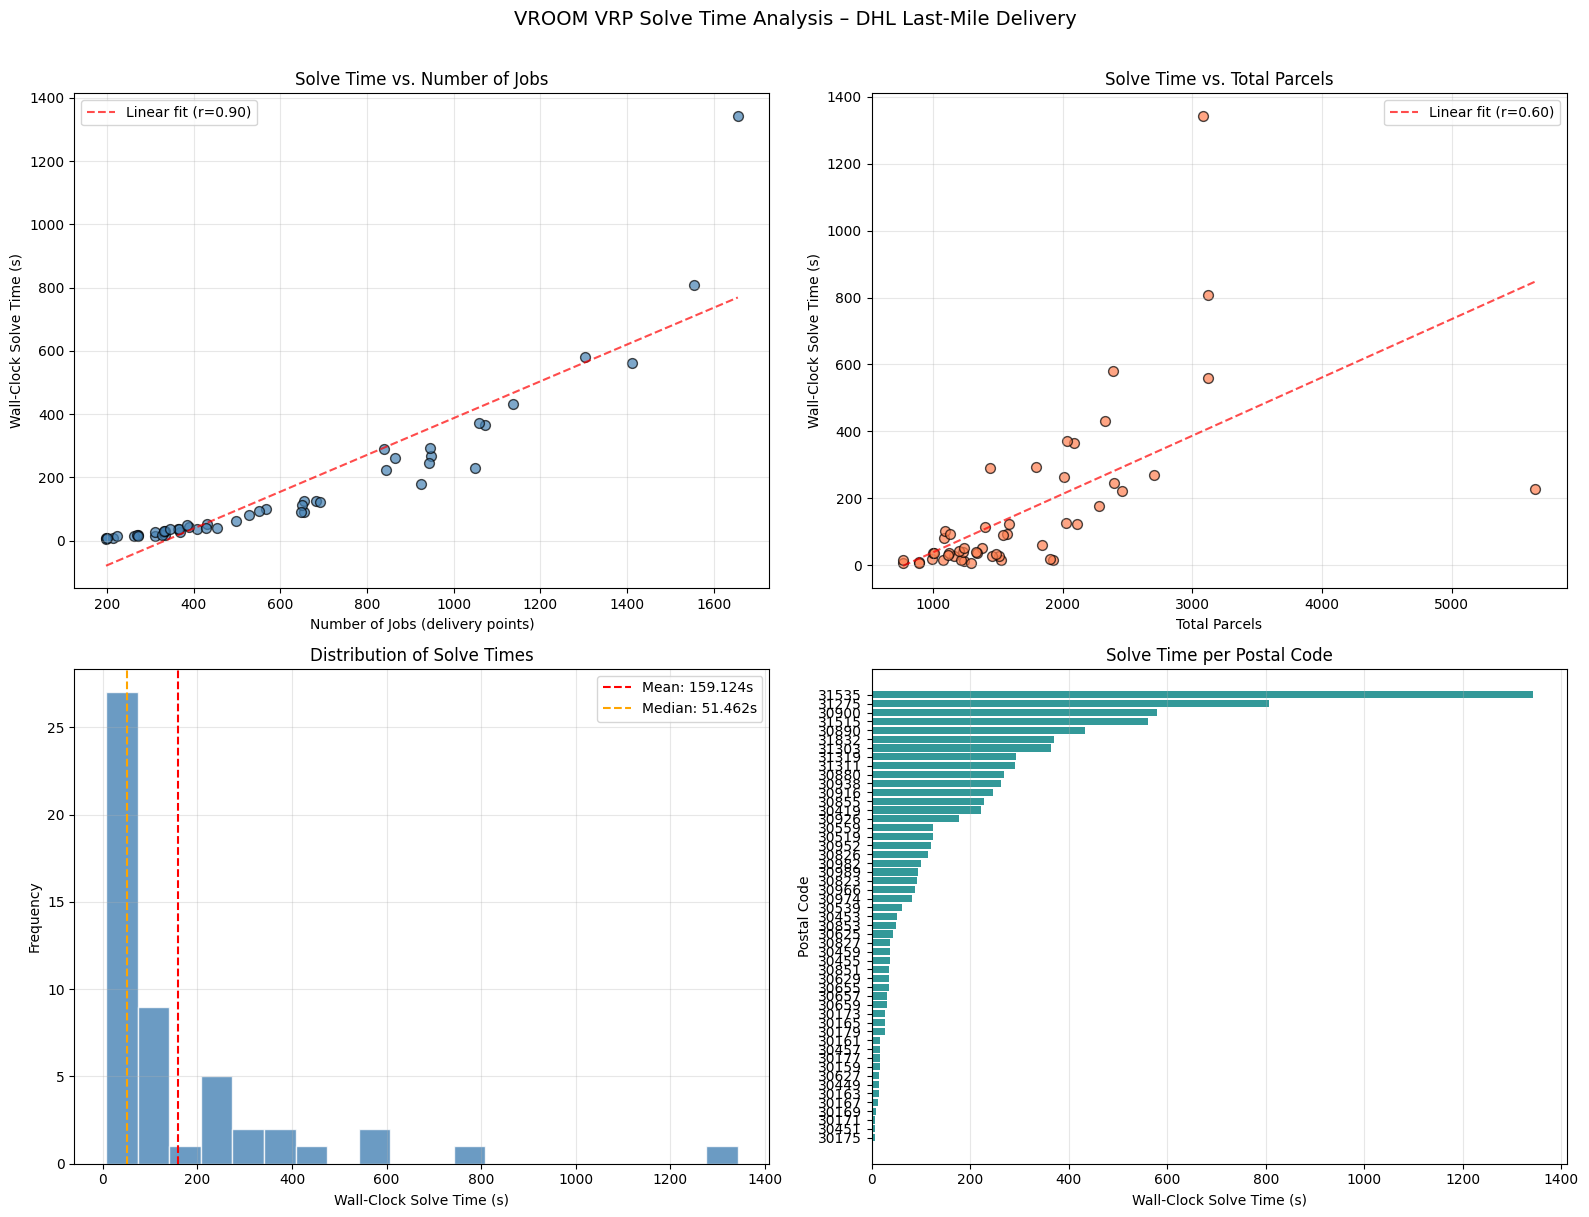

20:52:16 [INFO] Runtime plots generated


In [47]:
# ── Runtime visualisation ────────────────────────────────────────────────────
if len(df_ok) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # (a) Scatter: wall-clock solve time vs. number of jobs
    ax = axes[0, 0]
    ax.scatter(df_ok['n_jobs'], df_ok['solve_time_s'], c='steelblue', alpha=0.7, edgecolors='k', s=50)
    ax.set_xlabel('Number of Jobs (delivery points)')
    ax.set_ylabel('Wall-Clock Solve Time (s)')
    ax.set_title('Solve Time vs. Number of Jobs')
    # Trend line
    if len(df_ok) > 2:
        z = np.polyfit(df_ok['n_jobs'], df_ok['solve_time_s'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(df_ok['n_jobs'].min(), df_ok['n_jobs'].max(), 100)
        ax.plot(x_range, p(x_range), '--', color='red', alpha=0.7,
                label=f'Linear fit (r={df_ok["solve_time_s"].corr(df_ok["n_jobs"]):.2f})')
        ax.legend()
    ax.grid(True, alpha=0.3)
    
    # (b) Scatter: solve time vs. total parcels
    ax = axes[0, 1]
    ax.scatter(df_ok['total_parcels'], df_ok['solve_time_s'], c='coral', alpha=0.7, edgecolors='k', s=50)
    ax.set_xlabel('Total Parcels')
    ax.set_ylabel('Wall-Clock Solve Time (s)')
    ax.set_title('Solve Time vs. Total Parcels')
    if len(df_ok) > 2:
        z = np.polyfit(df_ok['total_parcels'], df_ok['solve_time_s'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(df_ok['total_parcels'].min(), df_ok['total_parcels'].max(), 100)
        ax.plot(x_range, p(x_range), '--', color='red', alpha=0.7,
                label=f'Linear fit (r={df_ok["solve_time_s"].corr(df_ok["total_parcels"]):.2f})')
        ax.legend()
    ax.grid(True, alpha=0.3)
    
    # (c) Histogram: solve time distribution
    ax = axes[1, 0]
    ax.hist(df_ok['solve_time_s'], bins=min(20, len(df_ok)), color='steelblue',
            edgecolor='white', alpha=0.8)
    ax.axvline(df_ok['solve_time_s'].mean(), color='red', linestyle='--',
               label=f'Mean: {df_ok["solve_time_s"].mean():.3f}s')
    ax.axvline(df_ok['solve_time_s'].median(), color='orange', linestyle='--',
               label=f'Median: {df_ok["solve_time_s"].median():.3f}s')
    ax.set_xlabel('Wall-Clock Solve Time (s)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Solve Times')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # (d) Bar chart: solve time per PLZ (sorted)
    ax = axes[1, 1]
    df_sorted = df_ok.sort_values('solve_time_s', ascending=True)
    ax.barh(df_sorted['plz'].astype(str), df_sorted['solve_time_s'], color='teal', alpha=0.8)
    ax.set_xlabel('Wall-Clock Solve Time (s)')
    ax.set_ylabel('Postal Code')
    ax.set_title('Solve Time per Postal Code')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.suptitle('VROOM VRP Solve Time Analysis – DHL Last-Mile Delivery', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
    log.info('Runtime plots generated')

In [75]:
# ── Save solve results and solutions ─────────────────────────────────────────
solve_csv_path = SOL_DIR / 'solve_metrics.csv'
df_solve.to_csv(solve_csv_path, index=False)

for plz_code, solution in solutions.items():
    sol_path = SOL_DIR / f'solution_{plz_code}.json'
    with open(sol_path, 'w', encoding='utf-8') as f:
        json.dump(solution, f, ensure_ascii=False, indent=2)

combined_sol_path = SOL_DIR / 'all_solutions.json'
with open(combined_sol_path, 'w', encoding='utf-8') as f:
    json.dump(solutions, f, ensure_ascii=False, indent=2)

log.info(f'{len(solutions)} solution files saved to: {SOL_DIR}')

print('\n' + '=' * 90)
print('SUMMARY: DHL Last-Mile VRP Results – Hannover Region')
print('=' * 90)
n_ok = (df_solve['status'] == 'OK').sum()
df_ok = df_solve[df_solve['status'] == 'OK']
print(f'  Postal codes solved:    {n_ok}/{len(df_solve)}')
print(f'  Total delivery points:  {df_ok["n_jobs"].sum()}')
print(f'  Total parcels:          {df_ok["total_parcels"].sum()}')
print(f'  Total vehicles used:    {df_ok["n_routes"].sum():.0f}')
print(f'  Unassigned jobs:        {df_ok["n_unassigned"].sum():.0f}')
print(f'  Total distance:         {df_ok["distance_m"].sum() / 1000:,.1f} km')
print(f'  Total duration:         {df_ok["duration_s"].sum() / 3600:,.1f} h')
print(f'  Total cost:             {df_ok["cost"].sum():,.0f}')
print(f'  Wall-clock (parallel):  {total_elapsed:.1f}s ({total_elapsed/60:.1f} min)')
print(f'  Speedup vs sequential:  {df_ok["solve_time_s"].sum() / total_elapsed:.2f}x')
print('=' * 90)

17:13:50 [INFO] 51 solution files saved to: c:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\results\dhl_per_plz



SUMMARY: DHL Last-Mile VRP Results – Hannover Region
  Postal codes solved:    51/51
  Total delivery points:  31011
  Total parcels:          86350
  Total vehicles used:    400
  Unassigned jobs:        0
  Total distance:         9,348.1 km
  Total duration:         494.8 h
  Total cost:             9,711,974
  Wall-clock (parallel):  2824.7s (47.1 min)
  Speedup vs sequential:  3.00x


In [76]:
# ── Post-Solve: Verkehrsfaktor-Validierung & Free-Flow-Vergleich ──────────────
# VROOM's speed_factor ist ein globaler Ø-Skalierungswert.
# Hier prüfen wir stepweise, wie stündliche Verkehrsfaktoren abweichen,
# und vergleichen die Ergebnisse mit Free-Flow (ohne speed_factor).

def get_traffic_factor(second_of_day):
    """Stundenfaktor für einen Zeitpunkt (Sekunden seit Mitternacht)."""
    hour = max(0, min(23, int(second_of_day) // 3600))
    return TRAFFIC_FACTORS[hour]

traffic_rows = []

for plz_code, sol in solutions.items():
    for route in sol.get('routes', []):
        vid = route['vehicle']
        steps = route.get('steps', [])
        
        orig_travel_with_sf = route.get('duration', 0)  # VROOM output (inkl. speed_factor)
        orig_service = route.get('service', 0)
        orig_waiting = route.get('waiting_time', 0)
        orig_distance = route.get('distance', 0)
        
        start_load = 0
        for s in steps:
            if s['type'] == 'start':
                start_load = s.get('load', [0])[0]
                break
        
        # Basis-Fahrzeit zurückrechnen (free-flow, ohne speed_factor)
        base_travel = orig_travel_with_sf * SPEED_FACTOR
        
        # Step-weise stündliche Korrektur
        hourly_corrected_travel = 0.0
        for i in range(len(steps) - 1):
            dep_time = steps[i].get('arrival', 0) + steps[i].get('service', 0) + steps[i].get('waiting_time', 0)
            arr_time = steps[i + 1].get('arrival', 0)
            leg_travel_sf = max(0, arr_time - dep_time)
            leg_travel_base = leg_travel_sf * SPEED_FACTOR
            
            if leg_travel_base > 0:
                hourly_factor = get_traffic_factor(dep_time)
                hourly_corrected_travel += leg_travel_base * hourly_factor
        
        if hourly_corrected_travel == 0 and base_travel > 0:
            mid = steps[0].get('arrival', 25200) + orig_travel_with_sf / 2
            hourly_corrected_travel = base_travel * get_traffic_factor(mid)
        
        # Abfahrt- und Ankunftszeiten
        start_time = steps[0].get('arrival', 0) if steps else 0
        end_time = steps[-1].get('arrival', 0) if steps else 0
        
        n_stops = sum(1 for s in steps if s['type'] == 'job')
        total_with_sf = orig_travel_with_sf + orig_service + orig_waiting
        total_base = base_travel + orig_service + orig_waiting
        total_hourly = hourly_corrected_travel + orig_service + orig_waiting
        
        traffic_rows.append({
            'plz': plz_code,
            'vehicle_id': vid,
            'n_stops': n_stops,
            'parcels': start_load,
            'distance_km': round(orig_distance / 1000, 2),
            'start_time': start_time,
            'end_time': end_time,
            # Free-Flow (Basis)
            'travel_base_h': round(base_travel / 3600, 3),
            'total_base_h': round(total_base / 3600, 3),
            # VROOM mit speed_factor (Ø-Korrektur)
            'travel_sf_h': round(orig_travel_with_sf / 3600, 3),
            'total_sf_h': round(total_with_sf / 3600, 3),
            # Stündliche Faktoren
            'travel_hourly_h': round(hourly_corrected_travel / 3600, 3),
            'total_hourly_h': round(total_hourly / 3600, 3),
            # Deltas
            'delta_vs_freeflow_min': round((orig_travel_with_sf - base_travel) / 60, 1),
            'delta_vs_freeflow_pct': round((orig_travel_with_sf / base_travel - 1) * 100, 1) if base_travel > 0 else 0,
            'load_factor': round(start_load / VEHICLE_CAPACITY, 3) if VEHICLE_CAPACITY > 0 else 0,
        })

df_traffic = pd.DataFrame(traffic_rows)

def _fmt_time(secs):
    h, m = divmod(int(secs), 3600)
    m = m // 60
    return f'{h:02d}:{m:02d}'

print('=' * 90)
print('   VERGLEICH: FREE-FLOW vs. VERKEHRSKORREKTUR (speed_factor)')
print('=' * 90)
print()
print(f'  Konfiguration:')
print(f'    Fahrzeug-Zeitfenster:   {_fmt_time(VEHICLE_TIME_WINDOW[0])} – {_fmt_time(VEHICLE_TIME_WINDOW[1])}  (inkl. Anfahrt)')
print(f'    Liefer-Zeitfenster:     {_fmt_time(DELIVERY_WINDOW[0])} – {_fmt_time(DELIVERY_WINDOW[1])}  (Jobs)')
print(f'    speed_factor:           {SPEED_FACTOR}  (≙ Ø ×{AVG_TRAFFIC_FACTOR:.4f})')
print()

t_base = df_traffic['travel_base_h'].sum()
t_sf = df_traffic['travel_sf_h'].sum()
t_hourly = df_traffic['travel_hourly_h'].sum()
t_total_base = df_traffic['total_base_h'].sum()
t_total_sf = df_traffic['total_sf_h'].sum()
t_total_hourly = df_traffic['total_hourly_h'].sum()
total_svc_h = df_traffic['total_sf_h'].sum() - df_traffic['travel_sf_h'].sum()
n_routes = len(df_traffic)

print('  ── Fahrzeit-Vergleich (alle {0} Touren) ──'.format(n_routes))
print(f'    Free-Flow (Basis):                {t_base:>8.1f} h')
print(f'    VROOM mit speed_factor:           {t_sf:>8.1f} h   (+{t_sf - t_base:.1f} h / +{(t_sf/t_base - 1)*100:.1f}%)')
print(f'    Step-weise stündl. Faktoren:      {t_hourly:>8.1f} h   (+{t_hourly - t_base:.1f} h / +{(t_hourly/t_base - 1)*100:.1f}%)')
print(f'    Abweichung Ø vs. stündlich:       {t_hourly - t_sf:>+8.1f} h   ({(t_hourly/t_sf - 1)*100:+.1f}%)')
print()
print('  ── Gesamtdauer-Vergleich ──')
print(f'    Free-Flow:                        {t_total_base:>8.1f} h   (Ø {df_traffic["total_base_h"].mean():.2f} h/Tour)')
print(f'    VROOM speed_factor:               {t_total_sf:>8.1f} h   (Ø {df_traffic["total_sf_h"].mean():.2f} h/Tour)  Δ +{t_total_sf - t_total_base:.1f} h')
print(f'    Stündliche Faktoren:              {t_total_hourly:>8.1f} h   (Ø {df_traffic["total_hourly_h"].mean():.2f} h/Tour)  Δ +{t_total_hourly - t_total_base:.1f} h')
print()

# Timing-Analyse: wann starten/enden Touren?
start_times = df_traffic['start_time']
end_times = df_traffic['end_time']
print('  ── Tour-Timing ──')
print(f'    Frühester Start:  {_fmt_time(start_times.min())}')
print(f'    Ø Start:          {_fmt_time(start_times.mean())}')
print(f'    Spätestes Ende:   {_fmt_time(end_times.max())}')
print(f'    Ø Ende:           {_fmt_time(end_times.mean())}')
# Wie viele starten vor 08:00 (nutzen Anfahrtspuffer)?
early_starts = (start_times < DELIVERY_WINDOW[0]).sum()
late_ends = (end_times > DELIVERY_WINDOW[1]).sum()
print(f'    Start vor {_fmt_time(DELIVERY_WINDOW[0])}:   {early_starts} Touren (nutzen Anfahrtspuffer)')
print(f'    Ende nach {_fmt_time(DELIVERY_WINDOW[1])}:  {late_ends} Touren (nutzen Rückfahrtpuffer)')
print()

# Zeitfenster-Verletzungen
MAX_SHIFT_H = (VEHICLE_TIME_WINDOW[1] - VEHICLE_TIME_WINDOW[0]) / 3600
violations = df_traffic[df_traffic['total_sf_h'] > MAX_SHIFT_H]
print(f'  ── Zeitfenster-Verletzungen (> {MAX_SHIFT_H:.0f}h Fahrzeug-Schicht) ──')
print(f'    {len(violations)} von {n_routes} Touren')
if len(violations) > 0:
    print(f'    → Längste Tour: {df_traffic["total_sf_h"].max():.2f} h')
    print(f'    → PLZ: {sorted(violations["plz"].unique())}')
print()
print(f'  ✓ Verkehrskorrektur:  Fahrzeit +{(t_sf/t_base - 1)*100:.1f}% vs. Free-Flow')
print(f'  ✓ Anfahrtspuffer:     {early_starts} Touren starten vor {_fmt_time(DELIVERY_WINDOW[0])}')
print('=' * 90)

   VERGLEICH: FREE-FLOW vs. VERKEHRSKORREKTUR (speed_factor)

  Konfiguration:
    Fahrzeug-Zeitfenster:   07:00 – 21:00  (inkl. Anfahrt)
    Liefer-Zeitfenster:     08:00 – 20:00  (Jobs)
    speed_factor:           0.859  (≙ Ø ×1.1643)

  ── Fahrzeit-Vergleich (alle 400 Touren) ──
    Free-Flow (Basis):                   425.1 h
    VROOM mit speed_factor:              494.8 h   (+69.8 h / +16.4%)
    Step-weise stündl. Faktoren:         503.2 h   (+78.2 h / +18.4%)
    Abweichung Ø vs. stündlich:           +8.4 h   (+1.7%)

  ── Gesamtdauer-Vergleich ──
    Free-Flow:                          3013.2 h   (Ø 7.53 h/Tour)
    VROOM speed_factor:                 3082.9 h   (Ø 7.71 h/Tour)  Δ +69.8 h
    Stündliche Faktoren:                3091.3 h   (Ø 7.73 h/Tour)  Δ +78.2 h

  ── Tour-Timing ──
    Frühester Start:  07:31
    Ø Start:          07:53
    Spätestes Ende:   20:18
    Ø Ende:           15:35
    Start vor 08:00:   228 Touren (nutzen Anfahrtspuffer)
    Ende nach 20:00:  1 

In [77]:
# ── Diagnose: Tourenlänge – Modell vs. Realität ──────────────────────────────
# Wie realistisch sind die Tourendauern nach der Service-Time-Korrektur?

import numpy as np

# Daten aus df_traffic (post-solve validation)
n_tours = len(df_traffic)
avg_stops = df_traffic['n_stops'].mean()
avg_parcels = df_traffic['parcels'].mean()
avg_travel_h = df_traffic['travel_sf_h'].mean()
avg_dist_km = df_traffic['distance_km'].mean()
avg_duration_h = df_traffic['total_sf_h'].mean()
total_stops = df_traffic['n_stops'].sum()
total_parcels = df_traffic['parcels'].sum()
avg_parcels_per_stop = total_parcels / total_stops
# Ø Servicezeit aus VROOM-Lösung (Summe der individuellen service-Zeiten)
avg_service_s = (avg_duration_h - avg_travel_h) * 3600  # Gesamtdauer - Fahrzeit
avg_service_min = avg_service_s / 60

# Realistische Zusatzzeiten (NICHT im Modell enthalten)
LOADING_TIME_MIN_REAL = 30       # Beladezeit am Hub
PARKING_WALK_S_REAL = 60         # Parkier-/Laufzeit pro Stopp
FAILED_DELIVERY_PCT = 0.10       # 10% gescheiterte Zustellversuche
BREAK_MIN_REAL = 30              # Pause bei >6h Tour

print('=' * 90)
print('   DIAGNOSE: Tourenlänge – Modell vs. Realität')
print('=' * 90)
print()
print('  ── Ist-Zustand im Modell (Ø pro Tour) ──')
print(f'    Stopps:           {avg_stops:.0f}')
print(f'    Pakete:           {avg_parcels:.0f}  ({avg_parcels_per_stop:.1f} Pakete/Stopp)')
print(f'    Distanz:          {avg_dist_km:.1f} km')
print(f'    Fahrzeit:         {avg_travel_h:.2f} h  ({avg_travel_h*60:.0f} min)')
print(f'    Servicezeit:      {avg_service_min:.0f} min  ({SERVICE_TIME_PER_PARCEL}s/Paket, max {SERVICE_TIME_CAP}s/Stopp)')
print(f'    Gesamtdauer:      {avg_duration_h:.2f} h  ({avg_duration_h*60:.0f} min)')
print(f'    Auslastung:       {avg_parcels/VEHICLE_CAPACITY*100:.1f}%  ({avg_parcels:.0f}/{VEHICLE_CAPACITY})')
print()

# ── ✓ Ursache 1 (BEHOBEN): Service-Time jetzt pro Paket ──
print('  ── ✓ Ursache 1 (BEHOBEN): Service-Time jetzt pro Paket ──')
print(f'    Vorher:           120s pauschal pro Stopp (egal wie viele Pakete)')
print(f'    Jetzt:            {SERVICE_TIME_PER_PARCEL}s × Pakete/Stopp, max {SERVICE_TIME_CAP//60} min')
print(f'    Effektive Ø:      {avg_service_s/avg_stops:.0f}s/Stopp  (bei {avg_parcels_per_stop:.1f} Pak/Stopp)')
print()

# ── Verbleibende Lücken zum realistischen Wert ──
walk_total_min = avg_stops * PARKING_WALK_S_REAL / 60
failed_extra_min = avg_parcels * FAILED_DELIVERY_PCT * SERVICE_TIME_PER_PARCEL / 60

print('  ── Verbleibende Lücken (nicht im Modell) ──')
print(f'    Beladezeit Hub:              +{LOADING_TIME_MIN_REAL} min')
print(f'    Park-/Laufwege:              +{walk_total_min:.0f} min  ({avg_stops:.0f} Stopps × {PARKING_WALK_S_REAL}s)')
print(f'    Pausen:                      +{BREAK_MIN_REAL} min')
print(f'    Gescheiterte Zustellungen:   +{failed_extra_min:.0f} min  ({FAILED_DELIVERY_PCT*100:.0f}%)')
print()

real_additions_min = LOADING_TIME_MIN_REAL + walk_total_min + BREAK_MIN_REAL + failed_extra_min
real_estimate_h = avg_duration_h + real_additions_min / 60

print('  ═══════════════════════════════════════════════════════════════════')
print('   ZUSAMMENFASSUNG')
print('  ═══════════════════════════════════════════════════════════════════')
print(f'    Modell-Tour (Ø):              {avg_duration_h:.1f} h  ({avg_duration_h*60:.0f} min)')
print(f'    + verbleibende Lücken:        +{real_additions_min:.0f} min  (+{real_additions_min/60:.1f} h)')
print(f'    ➜ Realistischer Schätzwert:   {real_estimate_h:.1f} h  ({real_estimate_h*60:.0f} min)')
print(f'    ➜ Typische DHL-LMD-Tour:      7–9 h  (Branchenkenntnis)')
print('  ═══════════════════════════════════════════════════════════════════')

   DIAGNOSE: Tourenlänge – Modell vs. Realität

  ── Ist-Zustand im Modell (Ø pro Tour) ──
    Stopps:           78
    Pakete:           216  (2.8 Pakete/Stopp)
    Distanz:          23.4 km
    Fahrzeit:         1.24 h  (74 min)
    Servicezeit:      388 min  (120s/Paket, max 900s/Stopp)
    Gesamtdauer:      7.71 h  (462 min)
    Auslastung:       93.9%  (216/230)

  ── ✓ Ursache 1 (BEHOBEN): Service-Time jetzt pro Paket ──
    Vorher:           120s pauschal pro Stopp (egal wie viele Pakete)
    Jetzt:            120s × Pakete/Stopp, max 15 min
    Effektive Ø:      300s/Stopp  (bei 2.8 Pak/Stopp)

  ── Verbleibende Lücken (nicht im Modell) ──
    Beladezeit Hub:              +30 min
    Park-/Laufwege:              +78 min  (78 Stopps × 60s)
    Pausen:                      +30 min
    Gescheiterte Zustellungen:   +43 min  (10%)

  ═══════════════════════════════════════════════════════════════════
   ZUSAMMENFASSUNG
  ══════════════════════════════════════════════════════════════